# Análisis Exploratorio de Datos (EDA) - Predicción de Riesgo Crediticio

**Autor:** Juan Carlos López S. 
**Fecha:** Mayo 2026  
**Objetivo:** Realizar un análisis exploratorio exhaustivo del dataset histórico de créditos para identificar patrones, relaciones y características clave que permitan predecir si un cliente pagará a tiempo su préstamo.

---

## Contenido

1. [Exploración Inicial](#1.-Exploración-Inicial)
2. [Análisis Univariado](#2.-Análisis-Univariado)
3. [Análisis Bivariado](#3.-Análisis-Bivariado)
4. [Análisis Multivariado](#4.-Análisis-Multivariado)
5. [Conclusiones y Recomendaciones](#5.-Conclusiones-y-Recomendaciones)

## 0. Configuración e Importación de Librerías

In [1]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Librerías estadísticas
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Exploración Inicial

### 1.1 Carga de Datos

In [2]:
# Importar función de carga desde el módulo cargar_datos
from cargar_datos import load_data, validate_data, get_data_summary

# Cargar datos
df = load_data('../../Base_de_datos.xlsx')

# Validar datos
is_valid, validation_report = validate_data(df)

# Mostrar resumen
get_data_summary(df)

✓ Datos cargados exitosamente: 10763 registros x 23 columnas
⚠ Advertencia: Desbalance de clases detectado (ratio: 0.050)
⚠ Advertencia: 1 tipos de valores fuera de rango detectados
✓ Validación exitosa: Dataset cumple con los requisitos mínimos

RESUMEN DE DATOS

Dimensiones: 10763 registros x 23 columnas

Variables numéricas: 20
Variables categóricas: 2
Variables fecha: 1

Valores nulos por columna:
  - tendencia_ingresos: 2932 (27.24%)
  - promedio_ingresos_datacredito: 2930 (27.22%)
  - saldo_mora_codeudor: 590 (5.48%)
  - saldo_principal: 405 (3.76%)
  - saldo_mora: 156 (1.45%)
  - saldo_total: 156 (1.45%)
  - puntaje_datacredito: 6 (0.06%)

Distribución variable objetivo (Pago_atiempo):
  - Pagó a tiempo (1): 10252 (95.25%)
  - No pagó a tiempo (0): 511 (4.75%)


### 1.2 Primeras Observaciones

In [3]:
# Visualizar primeros registros
print("Primeras 10 filas del dataset:")
df.head(10)

Primeras 10 filas del dataset:


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.000,10,42,Independiente,8000000,2500000,341296,88.768,695.000,10,5,0.000,51258.000,51258.000,0.000,5,0,0,908526.000,Estable,1
1,4,2025-04-22 09:47:35,840000.000,6,60,Empleado,3000000,2000000,124876,95.228,789.000,3,1,0.000,8673.000,8673.000,0.000,0,0,2,939017.000,Creciente,1
2,9,2026-01-08 12:22:40,5974028.400,10,36,Independiente,4036000,829000,529554,47.614,740.000,4,5,0.000,18702.000,18702.000,0.000,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.000,6,48,Empleado,1524547,498000,252420,95.228,837.000,4,4,0.000,15782.000,15782.000,0.000,3,0,0,1536193.000,Creciente,1
4,9,2025-04-26 11:24:26,2781636.000,11,44,Empleado,5000000,4000000,217037,95.228,771.000,4,6,0.000,204804.000,204804.000,0.000,3,0,1,933473.000,Creciente,1
5,4,2025-06-10 08:54:01,1031928.000,12,32,Empleado,2800000,800000,82872,95.228,721.000,10,13,0.000,24399.000,24399.000,0.000,2,0,8,2808474.000,Creciente,1
6,4,2025-08-09 13:00:44,3064280.400,6,68,Independiente,1000000,22005000,461231,95.228,814.000,11,8,0.000,211775.000,211775.000,0.000,6,3,0,969508.000,Creciente,1
7,4,2025-08-18 12:49:19,3619560.000,6,31,Empleado,3782303,305000,542079,95.228,760.000,1,5,0.000,12078.000,12078.000,0.000,0,1,0,3782303.000,Creciente,1
8,9,2025-05-30 09:11:18,2134827.600,10,31,Empleado,14500000,8000000,181732,95.228,737.000,0,2,0.000,0.000,NaN,NaN,0,0,0,14007850.000,Creciente,1
9,4,2024-12-31 14:32:59,8400000.000,6,45,Empleado,14000000,5000000,1166667,95.228,752.000,4,3,0.000,125383.000,125383.000,0.000,2,0,0,28889623.000,Creciente,1


In [4]:
# Información general del dataset
print("Información del Dataset:")
df.info()

Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64   

### 1.3 Identificación de la Variable Objetivo

**Variable objetivo:** `Pago_atiempo`
- **Tipo:** Binaria (0: No pagó a tiempo, 1: Pagó a tiempo)
- **Significado:** Indica si el cliente cumplió con los pagos de su crédito en las fechas pactadas

In [5]:
# Distribución de la variable objetivo
print("Distribución de la variable objetivo (Pago_atiempo):")
target_counts = df['Pago_atiempo'].value_counts()
target_pct = df['Pago_atiempo'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Frecuencia': target_counts,
    'Porcentaje': target_pct
})
target_summary.index = ['No pagó a tiempo', 'Pagó a tiempo']
print(target_summary)

# Ratio de desbalance
balance_ratio = target_counts.min() / target_counts.max()
print(f"\n⚠ Ratio de desbalance: {balance_ratio:.3f} (Clase minoritaria / Clase mayoritaria)")
print(f"⚠ El dataset está muy desbalanceado: {target_pct[1]:.2f}% pagaron a tiempo vs {target_pct[0]:.2f}% no pagaron")

Distribución de la variable objetivo (Pago_atiempo):
                  Frecuencia  Porcentaje
No pagó a tiempo       10252      95.252
Pagó a tiempo            511       4.748

⚠ Ratio de desbalance: 0.050 (Clase minoritaria / Clase mayoritaria)
⚠ El dataset está muy desbalanceado: 95.25% pagaron a tiempo vs 4.75% no pagaron


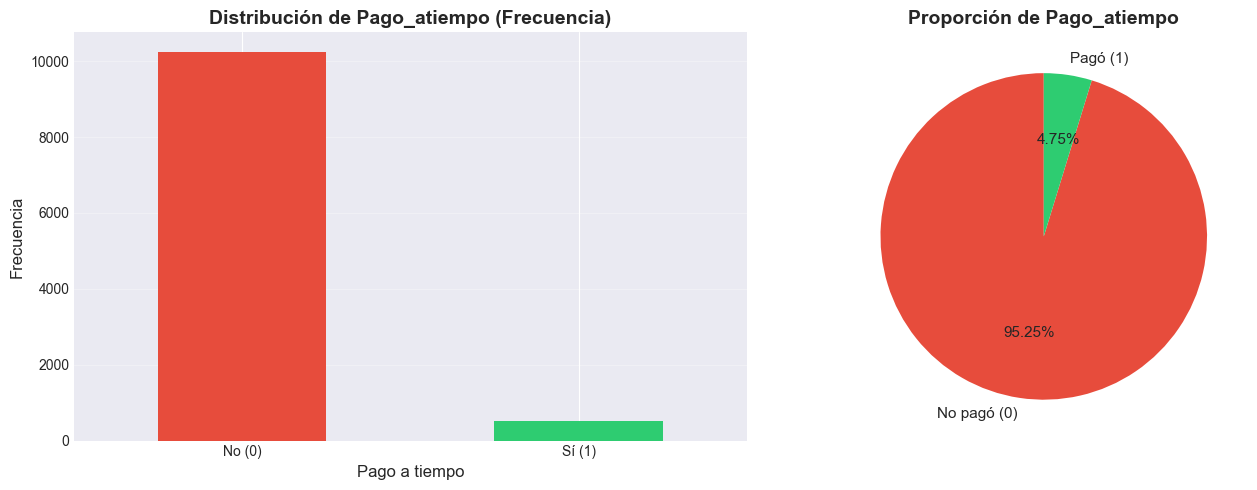


📊 INSIGHT: Existe un fuerte desbalance de clases (~95% pagaron a tiempo).
   Esto requerirá técnicas de balanceo en el modelado (SMOTE, class_weight, etc.)


In [6]:
# Visualización de la distribución del target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
target_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de Pago_atiempo (Frecuencia)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pago a tiempo', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pie
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(target_counts, labels=['No pagó (0)', 'Pagó (1)'], autopct='%1.2f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Proporción de Pago_atiempo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Existe un fuerte desbalance de clases (~95% pagaron a tiempo).")
print("   Esto requerirá técnicas de balanceo en el modelado (SMOTE, class_weight, etc.)")

### 1.4 Tipos de Variables

In [7]:
# Clasificar variables por tipo
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

# Remover la variable objetivo de las numéricas para análisis
numeric_features = [col for col in numeric_cols if col != 'Pago_atiempo']

print(f"Variables numéricas ({len(numeric_features)}): ")
print(numeric_features)
print(f"\nVariables categóricas ({len(categorical_cols)}): ")
print(categorical_cols)
print(f"\nVariables de fecha ({len(datetime_cols)}): ")
print(datetime_cols)

Variables numéricas (19): 
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas (2): 
['tipo_laboral', 'tendencia_ingresos']

Variables de fecha (1): 
['fecha_prestamo']


---

## 2. Análisis Univariado

### 2.1 Análisis de Valores Nulos

Variables con valores nulos:
                               Valores_Nulos  Porcentaje
tendencia_ingresos                      2932      27.241
promedio_ingresos_datacredito           2930      27.223
saldo_mora_codeudor                      590       5.482
saldo_principal                          405       3.763
saldo_mora                               156       1.449
saldo_total                              156       1.449
puntaje_datacredito                        6       0.056


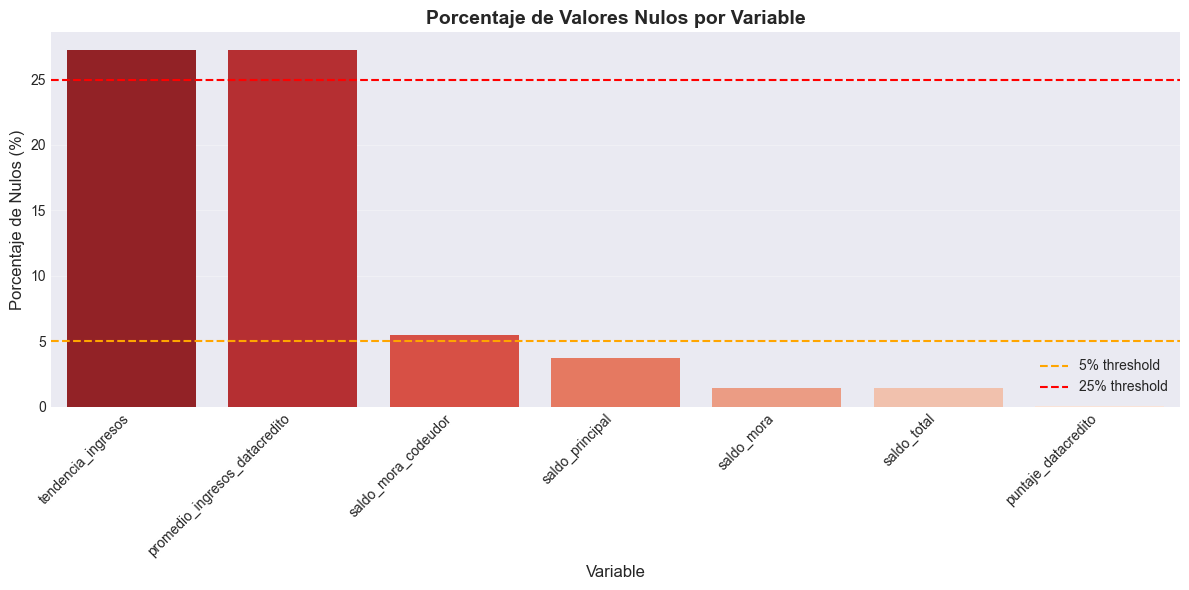


📊 INSIGHT: Variables de Datacredito tienen ~27% de valores nulos.
   Posibles razones: clientes sin historial crediticio o datos no disponibles.
   Estrategia: Imputar con mediana/moda o crear feature 'sin_historial_datacredito'.


In [8]:
# Valores nulos por columna
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

null_summary = pd.DataFrame({
    'Valores_Nulos': null_counts,
    'Porcentaje': null_pct
})
null_summary = null_summary[null_summary['Valores_Nulos'] > 0].sort_values('Porcentaje', ascending=False)

print("Variables con valores nulos:")
print(null_summary)

# Visualización de valores nulos
if len(null_summary) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=null_summary.index, y=null_summary['Porcentaje'], palette='Reds_r')
    plt.title('Porcentaje de Valores Nulos por Variable', fontsize=14, fontweight='bold')
    plt.xlabel('Variable', fontsize=12)
    plt.ylabel('Porcentaje de Nulos (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.axhline(y=5, color='orange', linestyle='--', label='5% threshold')
    plt.axhline(y=25, color='red', linestyle='--', label='25% threshold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 INSIGHT: Variables de Datacredito tienen ~27% de valores nulos.")
    print("   Posibles razones: clientes sin historial crediticio o datos no disponibles.")
    print("   Estrategia: Imputar con mediana/moda o crear feature 'sin_historial_datacredito'.")

### 2.2 Estadísticas Descriptivas - Variables Numéricas

In [9]:
# Estadísticas descriptivas de variables numéricas
print("Estadísticas descriptivas de variables numéricas:")
df[numeric_features].describe().T

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.000,5.411,2.338,4.000,4.000,4.000,9.000,68.000
capital_prestado,10763.000,2434315.001,1909642.759,360000.000,1224831.000,1921920.000,3084840.000,41444152.800
plazo_meses,10763.000,10.576,6.632,2.000,6.000,10.000,12.000,90.000
edad_cliente,10763.000,43.949,15.061,19.000,33.000,42.000,53.000,123.000
salario_cliente,10763.000,17216431.460,355476717.603,0.000,2000000.000,3000000.000,4875808.000,22000000000.000
total_otros_prestamos,10763.000,6238869.649,118418316.941,0.000,500000.000,1000000.000,2000000.000,6787675263.000
cuota_pactada,10763.000,243617.407,210493.695,23944.000,121041.500,182863.000,287833.500,3816752.000
puntaje,10763.000,91.170,16.465,-38.010,95.228,95.228,95.228,95.228
puntaje_datacredito,10757.000,780.791,104.878,-7.000,757.000,791.000,825.000,999.000
cant_creditosvigentes,10763.000,5.727,3.977,0.000,3.000,5.000,8.000,62.000


### 2.3 Distribución de Variables Numéricas - Histogramas

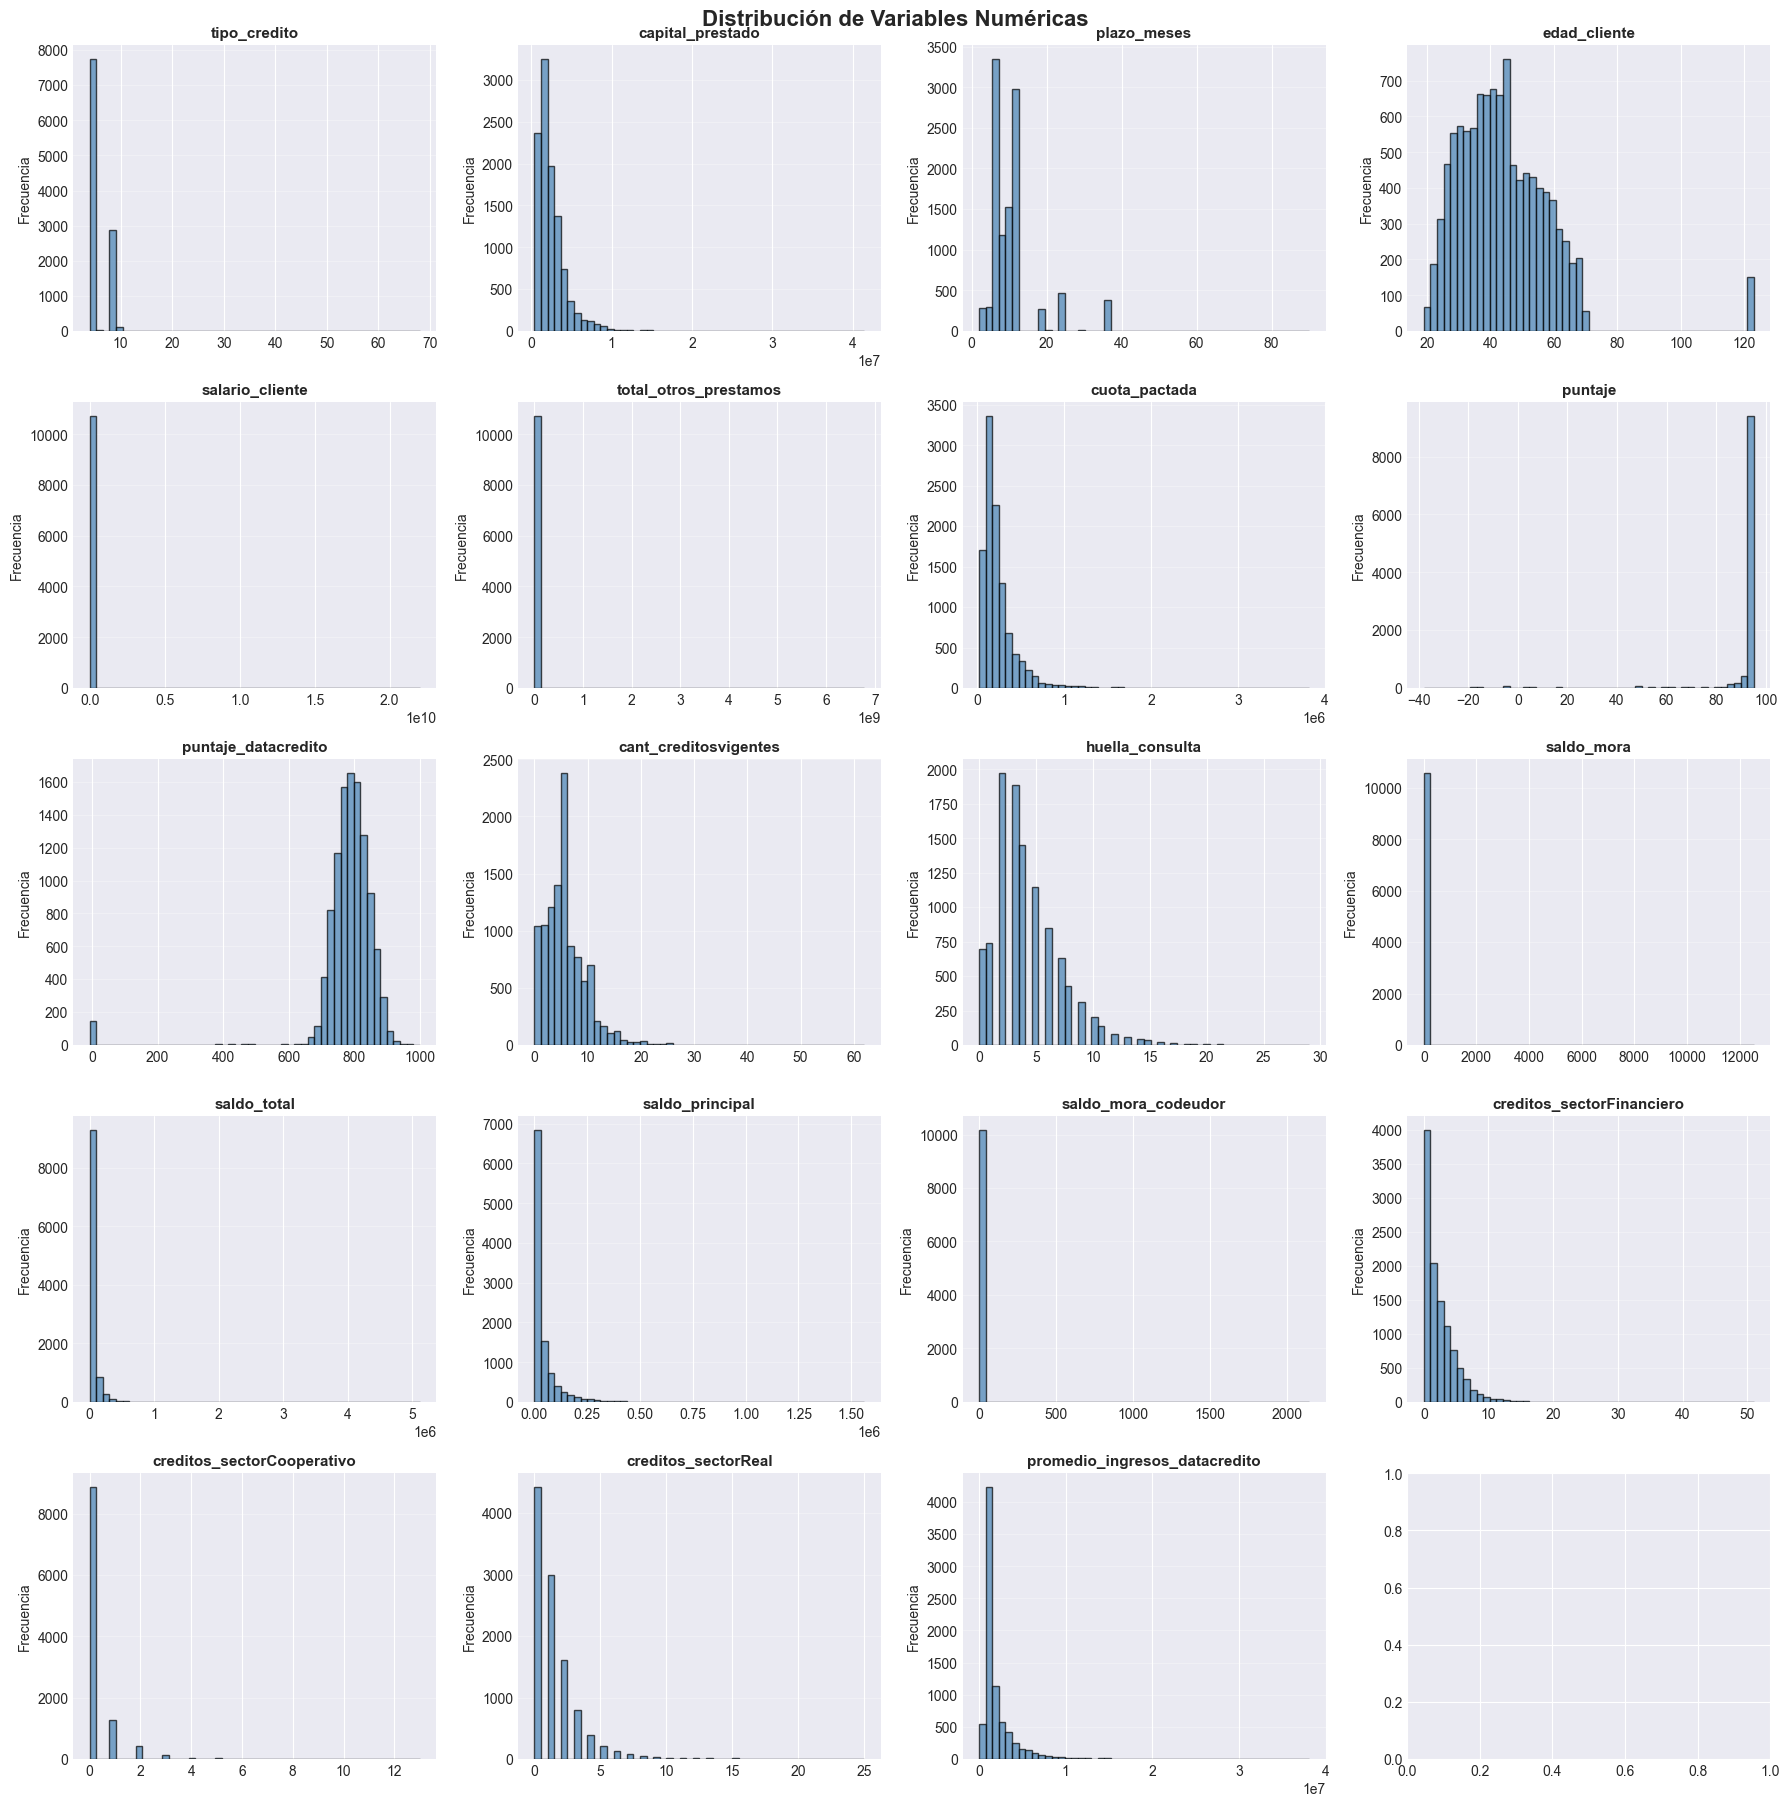


📊 INSIGHT: Observar asimetrías, outliers y rangos de valores para cada variable.


In [10]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("\n📊 INSIGHT: Observar asimetrías, outliers y rangos de valores para cada variable.")

### 2.4 Detección de Outliers - Boxplots

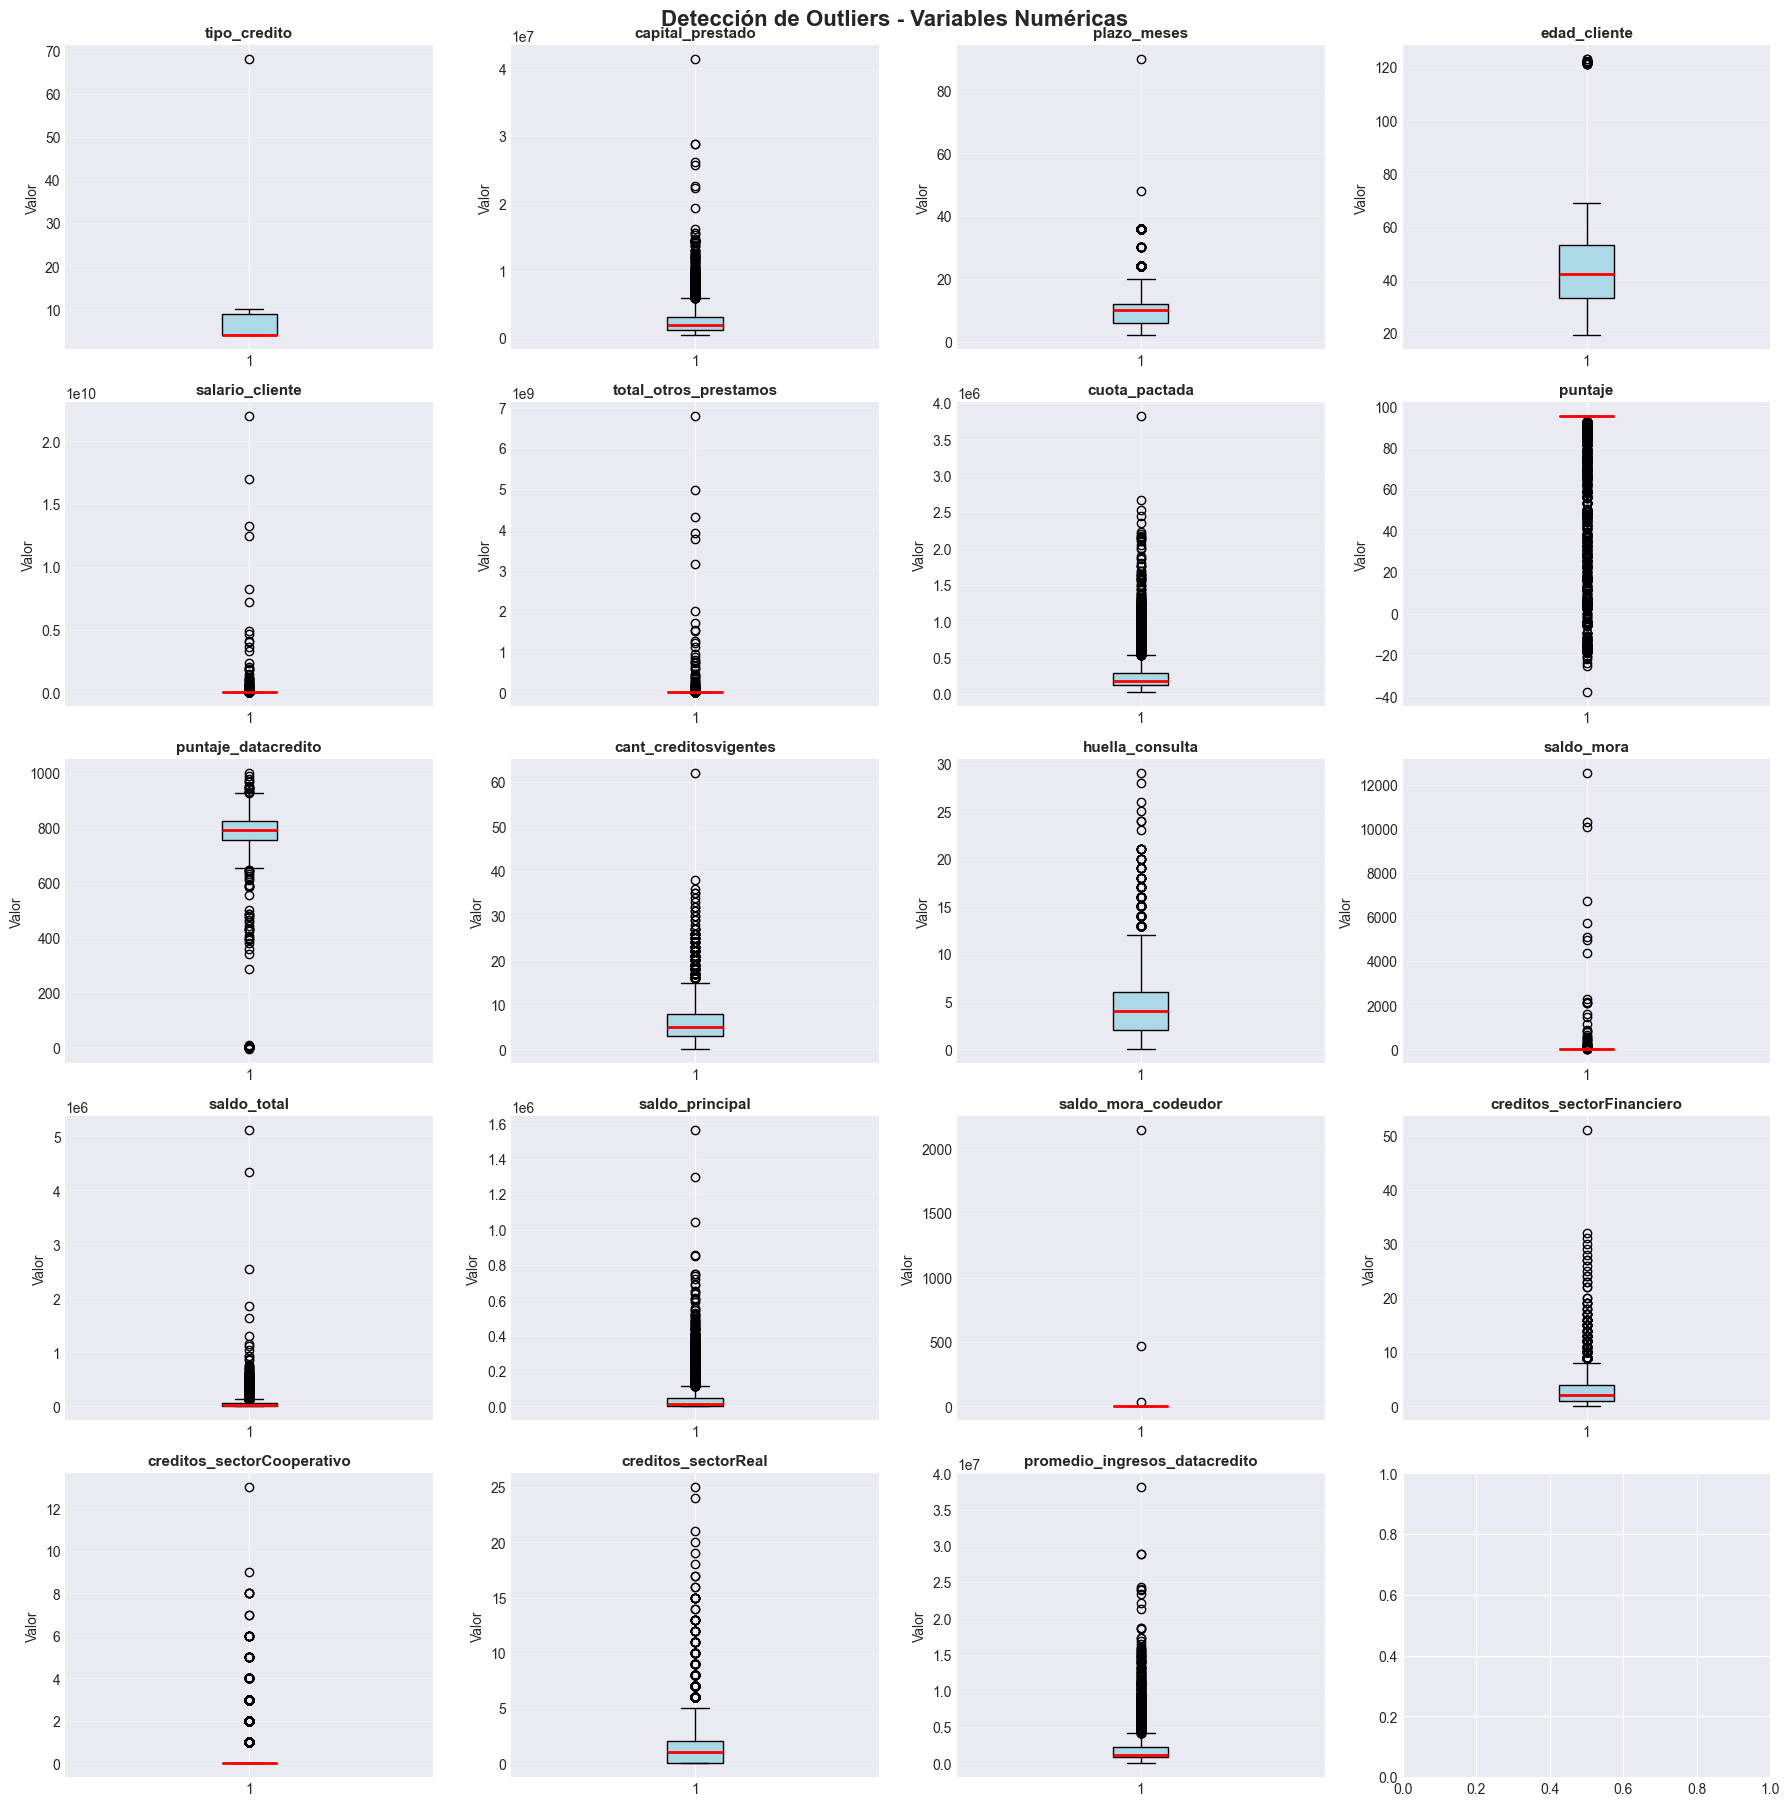


📊 INSIGHT: Identificar variables con outliers extremos que puedan requerir transformación.


In [11]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='black'),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Detección de Outliers - Variables Numéricas', fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("\n📊 INSIGHT: Identificar variables con outliers extremos que puedan requerir transformación.")

### 2.5 Análisis Cuantitativo de Outliers (IQR)

In [12]:
# Calcular outliers usando el método IQR (Rango Intercuartílico)
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outliers': outlier_count,
        'Porcentaje': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df['Outliers'] > 0].sort_values('Porcentaje', ascending=False)

print("Variables con outliers (método IQR):")
print(outlier_df)

print("\n📊 INSIGHT: Variables con >5% de outliers pueden requerir transformación (log, winsorización).")

Variables con outliers (método IQR):
                         Variable          Q1          Q3         IQR  \
16     creditos_sectorCooperativo       0.000       0.000       0.000   
7                         puntaje      95.228      95.228       0.000   
12                    saldo_total    2898.000   52982.000   50084.000   
13                saldo_principal    2690.000   47632.250   44942.250   
2                     plazo_meses       6.000      12.000       6.000   
18  promedio_ingresos_datacredito  925157.000 2231859.000 1306702.000   
6                   cuota_pactada  121041.500  287833.500  166792.000   
4                 salario_cliente 2000000.000 4875808.000 2875808.000   
5           total_otros_prestamos  500000.000 2000000.000 1500000.000   
1                capital_prestado 1224831.000 3084840.000 1860009.000   
15      creditos_sectorFinanciero       1.000       4.000       3.000   
17            creditos_sectorReal       0.000       2.000       2.000   
9           ca

### 2.6 Análisis de Variables Categóricas


Variable: tipo_laboral
               Frecuencia  Porcentaje
tipo_laboral                         
Empleado             6754      62.752
Independiente        4009      37.248

Número de categorías: 2
Valores nulos: 0


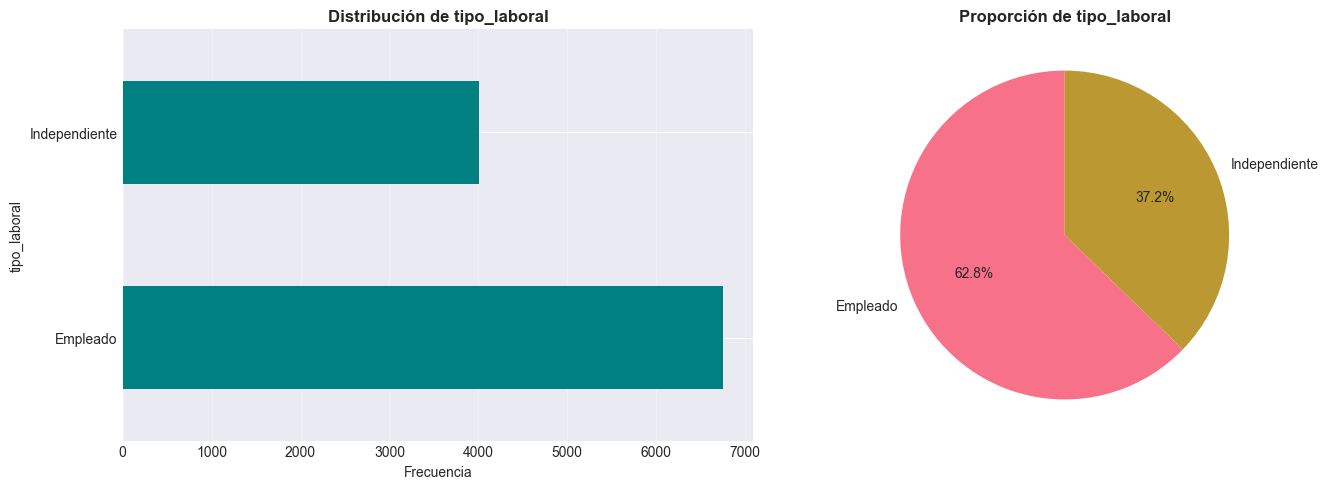


Variable: tendencia_ingresos
                    Frecuencia  Porcentaje
tendencia_ingresos                        
Creciente                 5294      67.603
Decreciente               1291      16.486
Estable                   1188      15.170
0                            7       0.089
8315                         6       0.077
1000000                      4       0.051
9147                         2       0.026
158042                       1       0.013
168750                       1       0.013
3978                         1       0.013
-28589                       1       0.013
-566272                      1       0.013
24702                        1       0.013
31837                        1       0.013
122727                       1       0.013
417087                       1       0.013
9090                         1       0.013
173031                       1       0.013
-70715                       1       0.013
-435177                      1       0.013
-702927                 

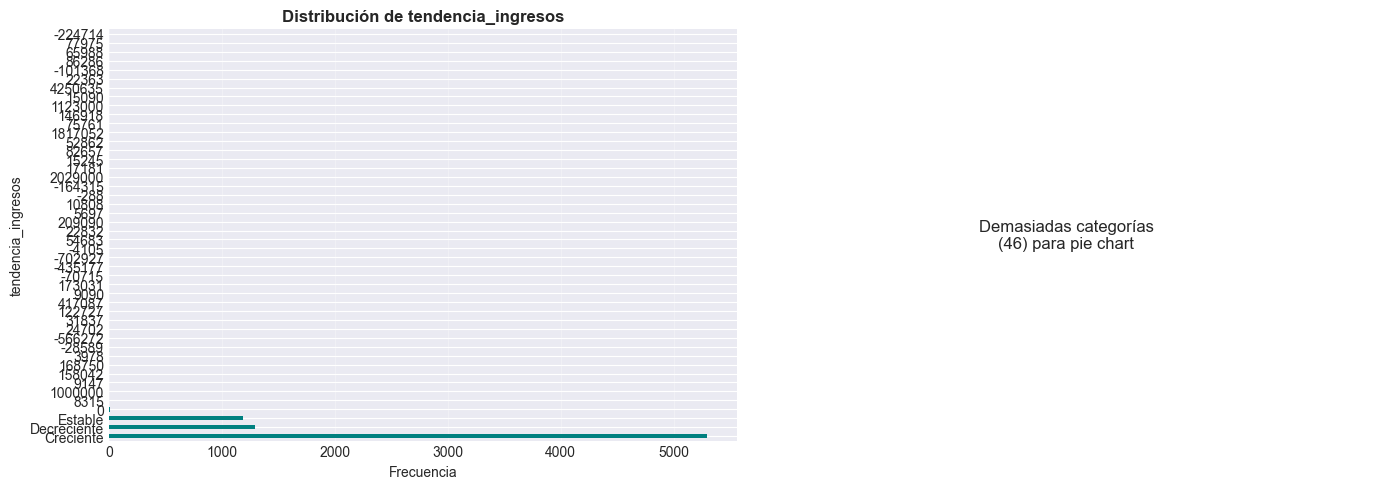

In [13]:
# Distribución de variables categóricas
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Variable: {col}")
    print(f"{'='*60}")
    
    value_counts = df[col].value_counts()
    value_pct = df[col].value_counts(normalize=True) * 100
    
    cat_summary = pd.DataFrame({
        'Frecuencia': value_counts,
        'Porcentaje': value_pct
    })
    
    print(cat_summary)
    print(f"\nNúmero de categorías: {df[col].nunique()}")
    print(f"Valores nulos: {df[col].isnull().sum()}")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    value_counts.plot(kind='barh', ax=axes[0], color='teal')
    axes[0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frecuencia')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Gráfico de pie (solo si no hay demasiadas categorías)
    if len(value_counts) <= 10:
        axes[1].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title(f'Proporción de {col}', fontsize=12, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, f'Demasiadas categorías\n({len(value_counts)}) para pie chart',
                    ha='center', va='center', fontsize=12)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

### 2.7 Análisis de Variable de Fecha

Análisis de fecha_prestamo:
Fecha mínima: 2024-11-26 09:17:04
Fecha máxima: 2026-04-26 18:43:52
Rango: 516 días


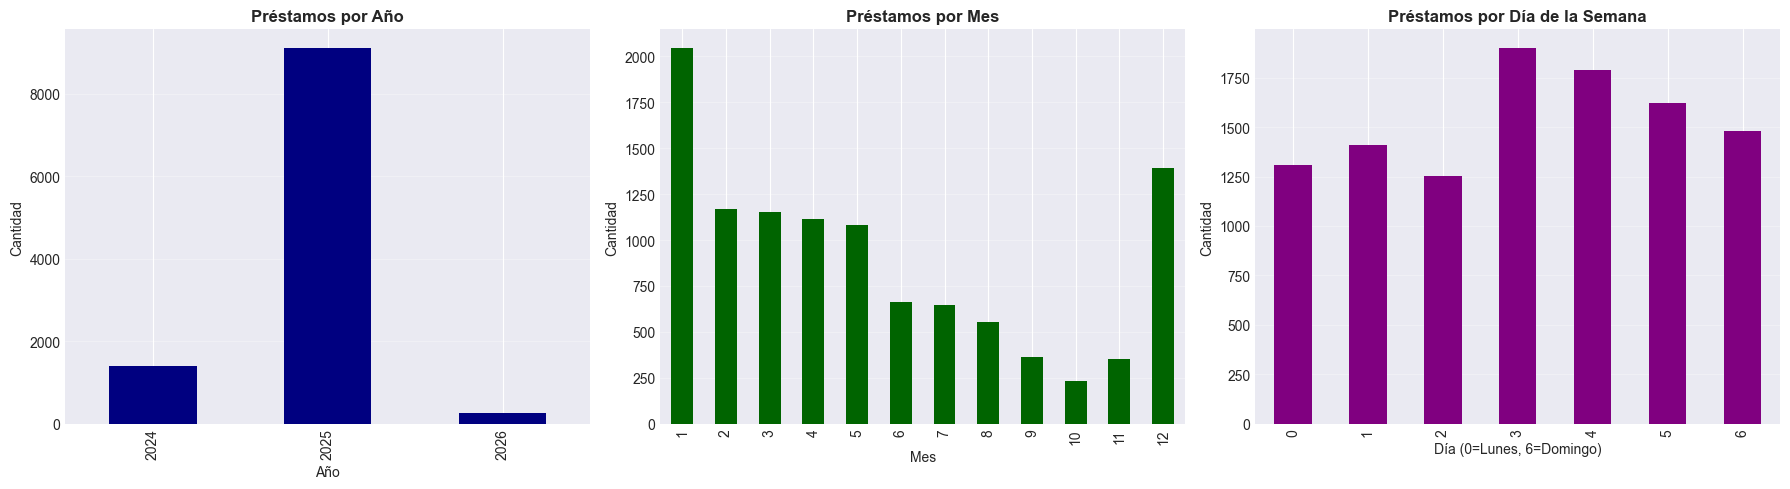


📊 INSIGHT: Estas features temporales pueden ser útiles para el modelo.


In [14]:
# Análisis de fecha_prestamo
if 'fecha_prestamo' in df.columns:
    print("Análisis de fecha_prestamo:")
    print(f"Fecha mínima: {df['fecha_prestamo'].min()}")
    print(f"Fecha máxima: {df['fecha_prestamo'].max()}")
    print(f"Rango: {(df['fecha_prestamo'].max() - df['fecha_prestamo'].min()).days} días")
    
    # Extraer componentes temporales
    df['año_prestamo'] = df['fecha_prestamo'].dt.year
    df['mes_prestamo'] = df['fecha_prestamo'].dt.month
    df['dia_semana_prestamo'] = df['fecha_prestamo'].dt.dayofweek
    
    # Visualización por año y mes
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Distribución por año
    df['año_prestamo'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='navy')
    axes[0].set_title('Préstamos por Año', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Cantidad')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Distribución por mes
    df['mes_prestamo'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='darkgreen')
    axes[1].set_title('Préstamos por Mes', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('Cantidad')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Distribución por día de la semana
    df['dia_semana_prestamo'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='purple')
    axes[2].set_title('Préstamos por Día de la Semana', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Día (0=Lunes, 6=Domingo)')
    axes[2].set_ylabel('Cantidad')
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 INSIGHT: Estas features temporales pueden ser útiles para el modelo.")

---

## 3. Análisis Bivariado

### 3.1 Matriz de Correlación - Variables Numéricas

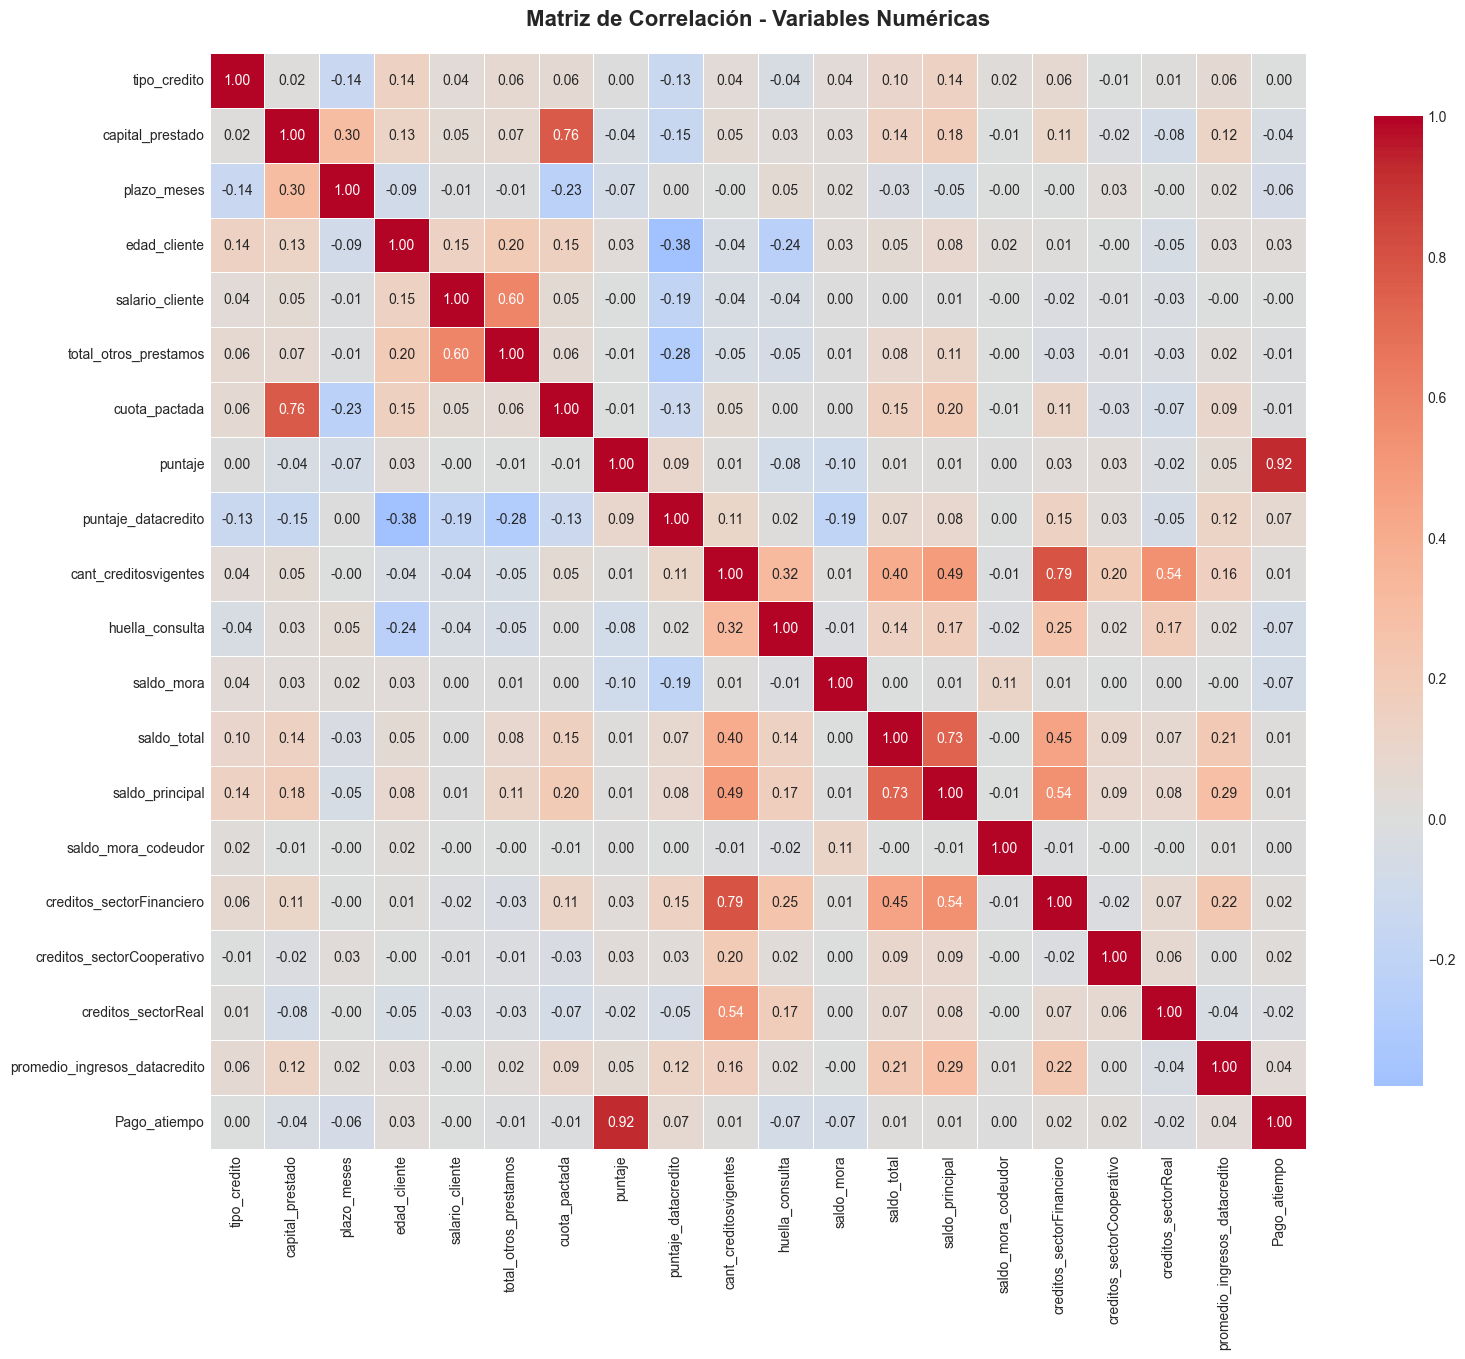


📊 INSIGHT: Identificar correlaciones fuertes (>0.7 o <-0.7) para detectar multicolinealidad.


In [15]:
# Matriz de correlación
correlation_matrix = df[numeric_cols].corr()

# Visualización con heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Identificar correlaciones fuertes (>0.7 o <-0.7) para detectar multicolinealidad.")

### 3.2 Correlación con la Variable Objetivo

Correlación de variables numéricas con Pago_atiempo:
puntaje                          0.923
puntaje_datacredito              0.068
promedio_ingresos_datacredito    0.040
edad_cliente                     0.032
creditos_sectorFinanciero        0.021
creditos_sectorCooperativo       0.021
saldo_total                      0.014
saldo_principal                  0.011
cant_creditosvigentes            0.009
saldo_mora_codeudor              0.003
tipo_credito                     0.001
salario_cliente                 -0.004
total_otros_prestamos           -0.010
cuota_pactada                   -0.012
creditos_sectorReal             -0.023
capital_prestado                -0.041
plazo_meses                     -0.063
saldo_mora                      -0.073
huella_consulta                 -0.074
Name: Pago_atiempo, dtype: float64


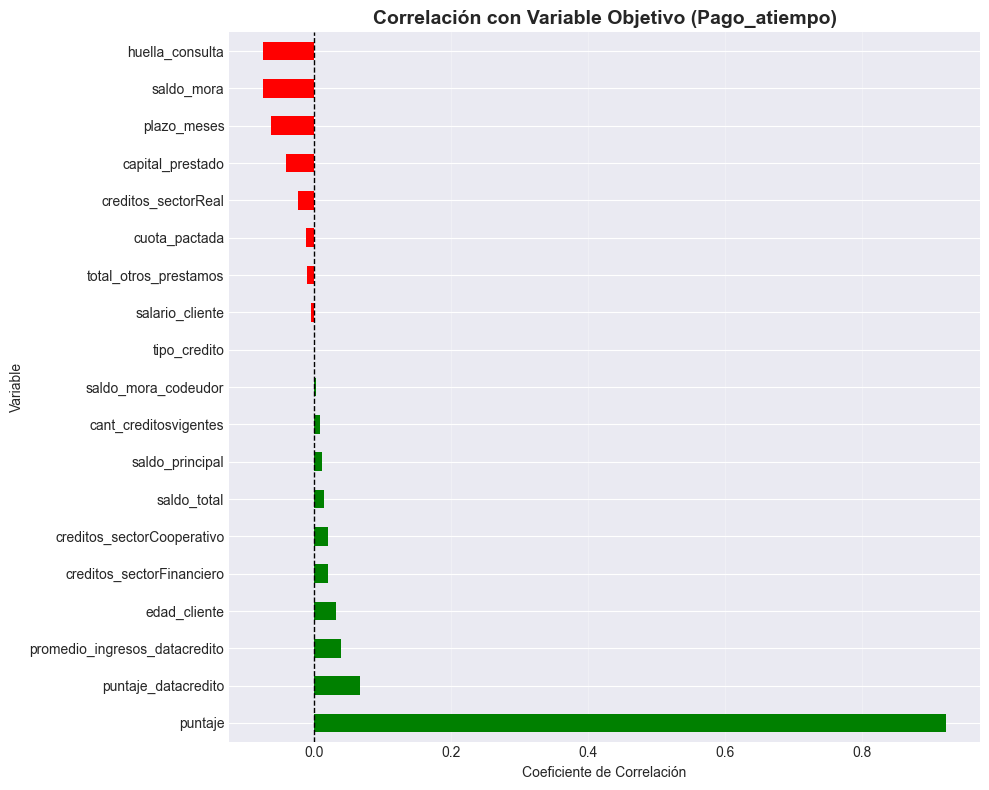


📊 INSIGHT: Variables con mayor correlación (positiva o negativa) son más importantes para el modelo.


In [16]:
# Correlación con Pago_atiempo
target_correlation = df[numeric_cols].corr()['Pago_atiempo'].sort_values(ascending=False)
target_correlation = target_correlation.drop('Pago_atiempo')  # Remover correlación consigo misma

print("Correlación de variables numéricas con Pago_atiempo:")
print(target_correlation)

# Visualización
plt.figure(figsize=(10, 8))
target_correlation.plot(kind='barh', color=target_correlation.apply(lambda x: 'green' if x > 0 else 'red'))
plt.title('Correlación con Variable Objetivo (Pago_atiempo)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variable')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Variables con mayor correlación (positiva o negativa) son más importantes para el modelo.")

### 3.3 Relación entre Variables Numéricas y Target (Boxplots)

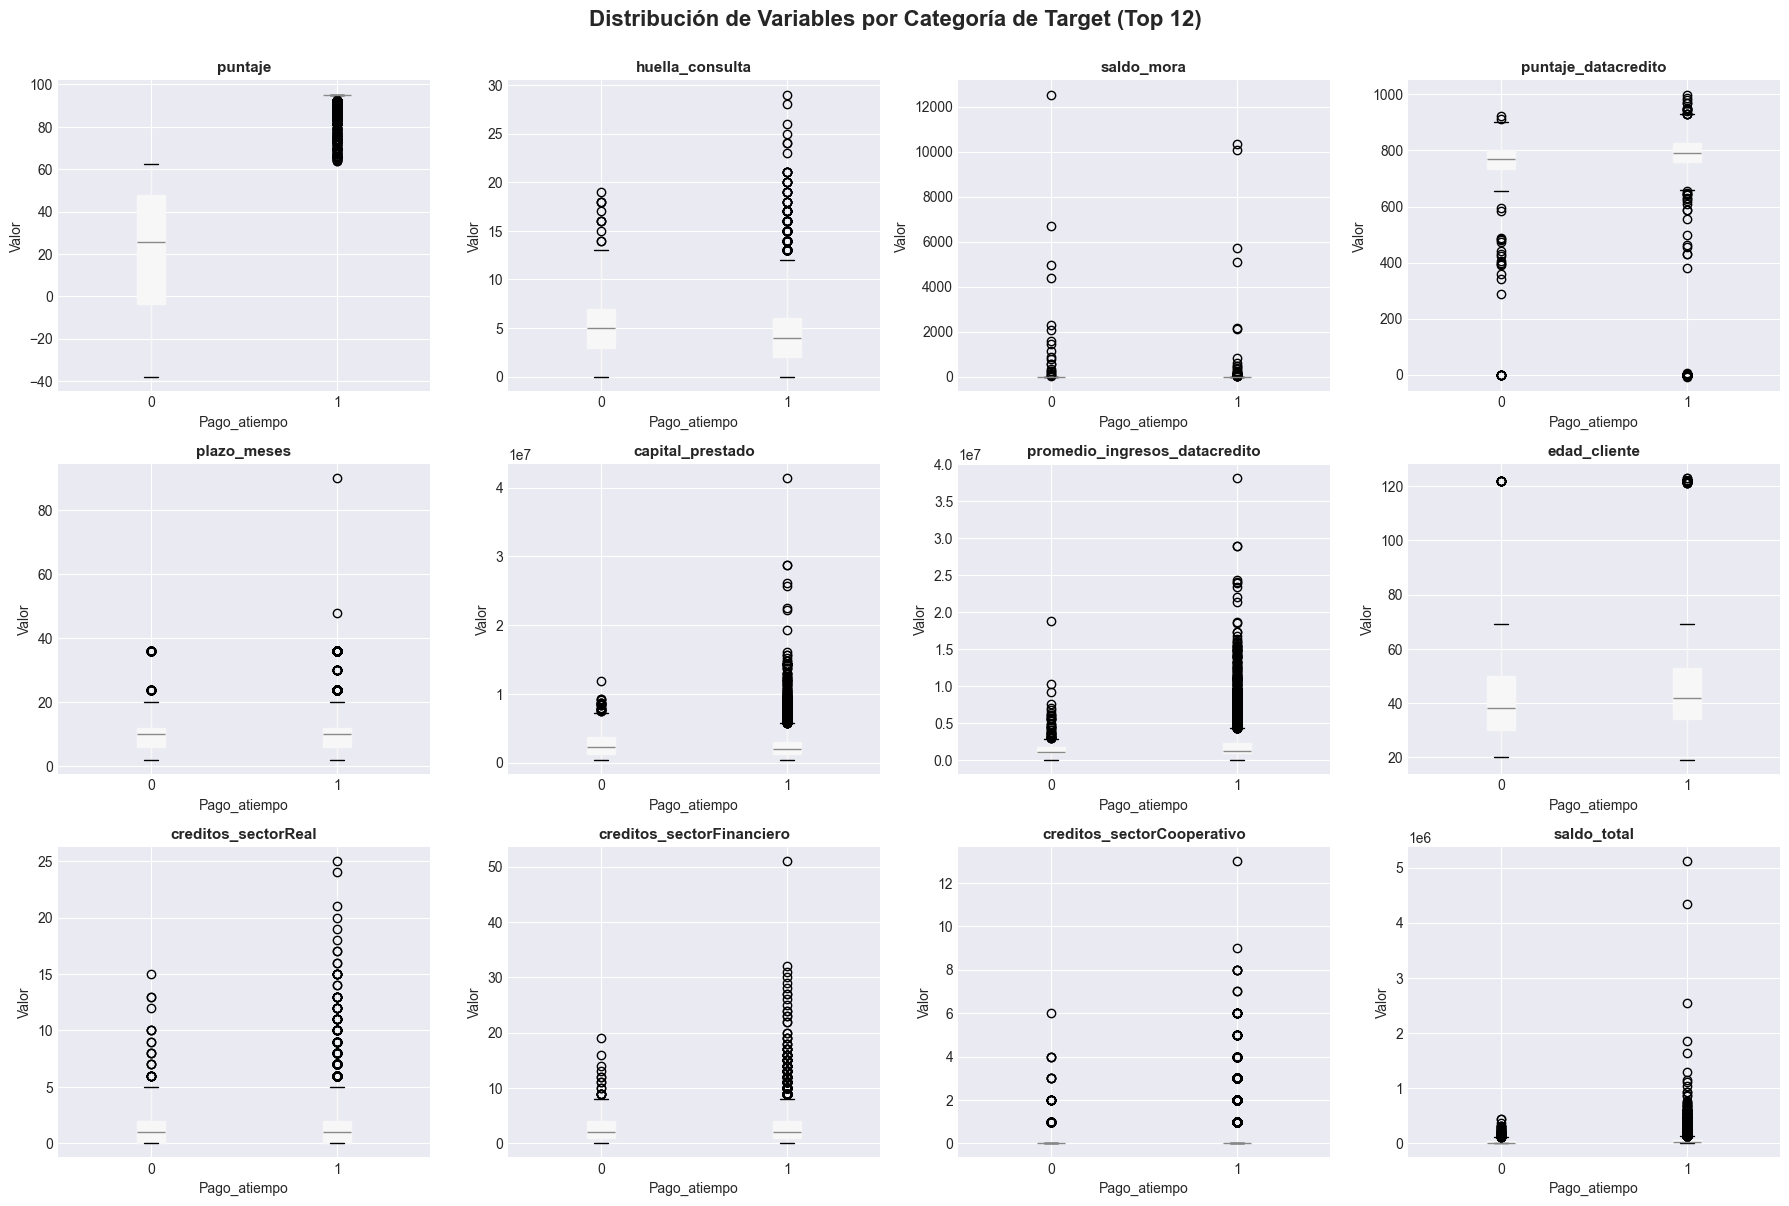


📊 INSIGHT: Diferencias significativas en medianas indican poder predictivo de la variable.


In [17]:
# Seleccionar las 12 variables numéricas más correlacionadas con el target
top_features = target_correlation.abs().sort_values(ascending=False).head(12).index.tolist()

# Boxplots por categoría de target
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(top_features):
    df.boxplot(column=col, by='Pago_atiempo', ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Pago_atiempo')
    axes[idx].set_ylabel('Valor')
    axes[idx].get_figure().suptitle('')  # Remover título automático

plt.suptitle('Distribución de Variables por Categoría de Target (Top 12)', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Diferencias significativas en medianas indican poder predictivo de la variable.")

### 3.4 Test Chi-Cuadrado: Variables Categóricas vs Target

In [18]:
# Test Chi-cuadrado para evaluar asociación entre variables categóricas y target
chi2_results = []

for col in categorical_cols:
    # Crear tabla de contingencia
    contingency_table = pd.crosstab(df[col], df['Pago_atiempo'])
    
    # Realizar test Chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi2_results.append({
        'Variable': col,
        'Chi2': chi2,
        'p-value': p_value,
        'Significativa': 'Sí' if p_value < 0.05 else 'No'
    })
    
    print(f"\nVariable: {col}")
    print(f"Chi2: {chi2:.4f}, p-value: {p_value:.6f}")
    if p_value < 0.05:
        print(f"✓ Hay asociación significativa con Pago_atiempo (p < 0.05)")
    else:
        print(f"✗ No hay asociación significativa con Pago_atiempo (p >= 0.05)")

chi2_df = pd.DataFrame(chi2_results)
print("\n" + "="*60)
print("Resumen Test Chi-Cuadrado:")
print(chi2_df)

print("\n📊 INSIGHT: Variables categóricas con p-value < 0.05 tienen relación significativa con el target.")


Variable: tipo_laboral
Chi2: 7.9968, p-value: 0.004686
✓ Hay asociación significativa con Pago_atiempo (p < 0.05)

Variable: tendencia_ingresos
Chi2: 16.6847, p-value: 0.999964
✗ No hay asociación significativa con Pago_atiempo (p >= 0.05)

Resumen Test Chi-Cuadrado:
             Variable   Chi2  p-value Significativa
0        tipo_laboral  7.997    0.005            Sí
1  tendencia_ingresos 16.685    1.000            No

📊 INSIGHT: Variables categóricas con p-value < 0.05 tienen relación significativa con el target.


### 3.5 Visualización: Variables Categóricas vs Target


Porcentaje de Pago_atiempo por tipo_laboral:
Pago_atiempo      0      1
tipo_laboral              
Empleado      4.294 95.706
Independiente 5.513 94.487


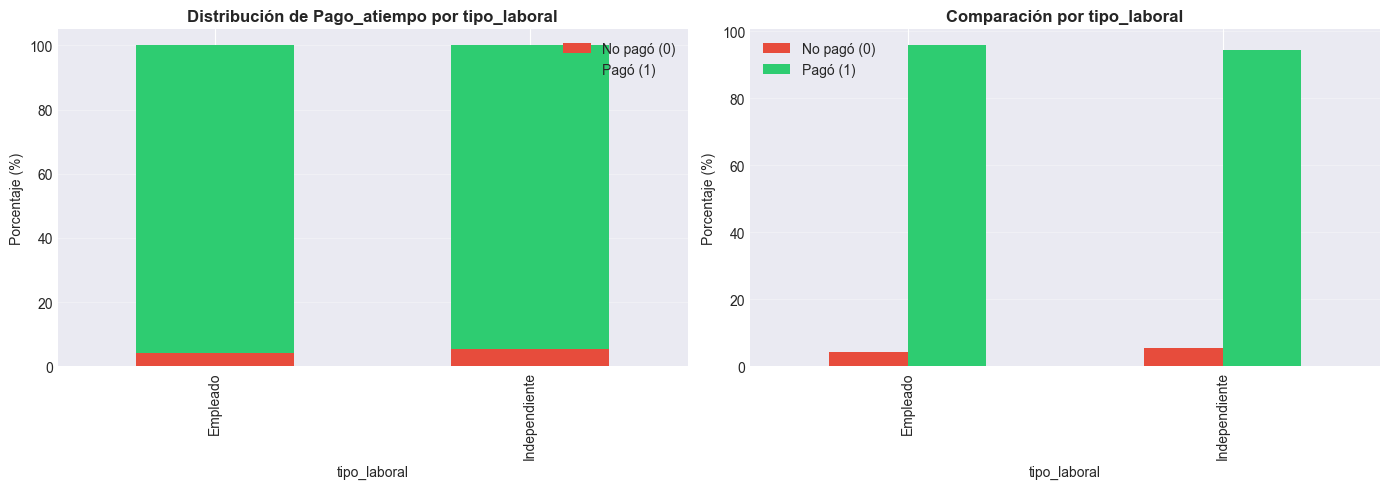


Porcentaje de Pago_atiempo por tendencia_ingresos:
Pago_atiempo           0       1
tendencia_ingresos              
-702927            0.000 100.000
-566272            0.000 100.000
-435177            0.000 100.000
-224714            0.000 100.000
-164315            0.000 100.000
-101368            0.000 100.000
-70715             0.000 100.000
-28589             0.000 100.000
-4105              0.000 100.000
-288               0.000 100.000
0                  0.000 100.000
3978               0.000 100.000
5697               0.000 100.000
8315               0.000 100.000
9090               0.000 100.000
9147               0.000 100.000
10808              0.000 100.000
15090              0.000 100.000
15245              0.000 100.000
17181              0.000 100.000
22363              0.000 100.000
22832              0.000 100.000
24702              0.000 100.000
31837              0.000 100.000
52862              0.000 100.000
54683              0.000 100.000
65988              0.000

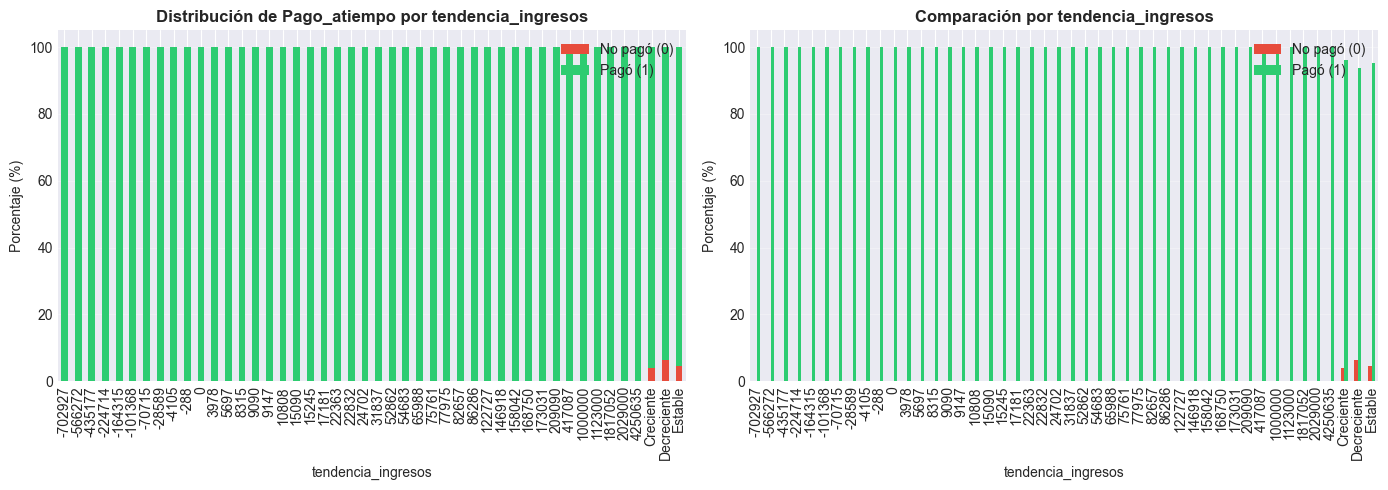

In [19]:
# Distribución del target por categoría
for col in categorical_cols:
    # Tabla de contingencia normalizada
    ct = pd.crosstab(df[col], df['Pago_atiempo'], normalize='index') * 100
    
    print(f"\nPorcentaje de Pago_atiempo por {col}:")
    print(ct)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras apiladas
    ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'])
    axes[0].set_title(f'Distribución de Pago_atiempo por {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Porcentaje (%)')
    axes[0].legend(['No pagó (0)', 'Pagó (1)'], loc='upper right')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Gráfico de barras agrupadas
    ct.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
    axes[1].set_title(f'Comparación por {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Porcentaje (%)')
    axes[1].legend(['No pagó (0)', 'Pagó (1)'])
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 3.6 Test ANOVA: Variables Numéricas vs Categorías del Target

In [20]:
# Test ANOVA para evaluar si hay diferencias significativas en medias de variables numéricas entre grupos del target
anova_results = []

for col in numeric_features:
    # Separar datos por grupo de target (0 y 1)
    group_0 = df[df['Pago_atiempo'] == 0][col].dropna()
    group_1 = df[df['Pago_atiempo'] == 1][col].dropna()
    
    # Realizar test ANOVA
    f_stat, p_value = f_oneway(group_0, group_1)
    
    anova_results.append({
        'Variable': col,
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Significativa': 'Sí' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results).sort_values('p-value')
print("Resultados Test ANOVA (Variables Numéricas vs Target):")
print(anova_df)

# Contar variables significativas
sig_count = (anova_df['p-value'] < 0.05).sum()
print(f"\n✓ {sig_count} de {len(numeric_features)} variables numéricas tienen diferencias significativas entre grupos (p < 0.05)")

print("\n📊 INSIGHT: Variables con p-value < 0.05 tienen medias diferentes entre quienes pagan y no pagan.")

Resultados Test ANOVA (Variables Numéricas vs Target):
                         Variable  F-Statistic  p-value Significativa
7                         puntaje    62035.647    0.000            Sí
10                huella_consulta       58.828    0.000            Sí
11                     saldo_mora       57.536    0.000            Sí
8             puntaje_datacredito       49.788    0.000            Sí
2                     plazo_meses       43.025    0.000            Sí
1                capital_prestado       17.788    0.000            Sí
18  promedio_ingresos_datacredito       12.466    0.000            Sí
3                    edad_cliente       11.205    0.001            Sí
17            creditos_sectorReal        5.848    0.016            Sí
15      creditos_sectorFinanciero        4.926    0.026            Sí
16     creditos_sectorCooperativo        4.869    0.027            Sí
12                    saldo_total        2.188    0.139            No
6                   cuota_pactada  

---

## 4. Análisis Multivariado

### 4.1 Pairplot - Top Variables Correlacionadas

Variables seleccionadas para pairplot: ['puntaje', 'huella_consulta', 'saldo_mora', 'puntaje_datacredito', 'plazo_meses', 'Pago_atiempo']


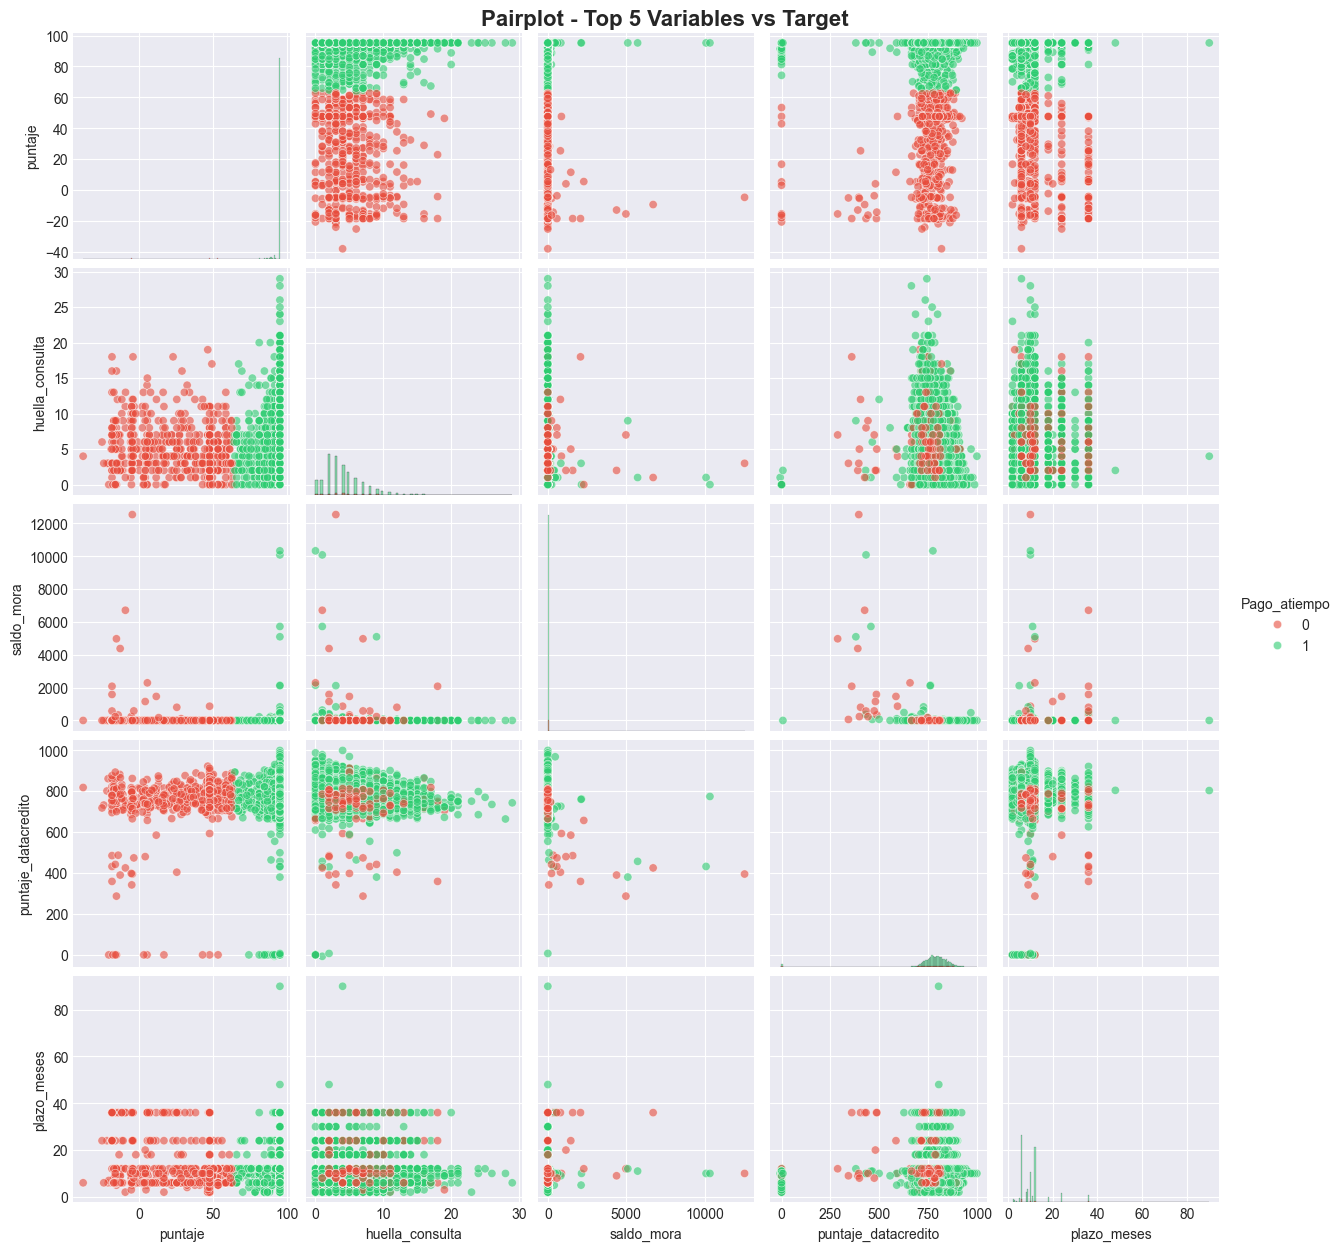


📊 INSIGHT: Buscar patrones de separación entre clases (rojo vs verde) en los scatter plots.


In [21]:
# Seleccionar top 5 variables más correlacionadas con target + target
top_5_features = target_correlation.abs().sort_values(ascending=False).head(5).index.tolist()
pairplot_cols = top_5_features + ['Pago_atiempo']

print(f"Variables seleccionadas para pairplot: {pairplot_cols}")

# Crear pairplot
sns.pairplot(df[pairplot_cols], hue='Pago_atiempo', palette={0: '#e74c3c', 1: '#2ecc71'},
             diag_kind='hist', plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot - Top 5 Variables vs Target', fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("\n📊 INSIGHT: Buscar patrones de separación entre clases (rojo vs verde) en los scatter plots.")

### 4.2 Análisis de Interacciones - Features Compuestas

Creando features de interacción...

✓ Features de interacción creadas: 6
['ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_prestamos_salario', 'carga_deuda_total', 'edad_fin_credito', 'total_creditos_activos']

Correlación de features de interacción con Pago_atiempo:
edad_fin_credito                0.030
total_creditos_activos          0.009
carga_deuda_total               0.004
ratio_otros_prestamos_salario   0.004
ratio_capital_salario           0.003
ratio_cuota_salario             0.002
Name: Pago_atiempo, dtype: float64


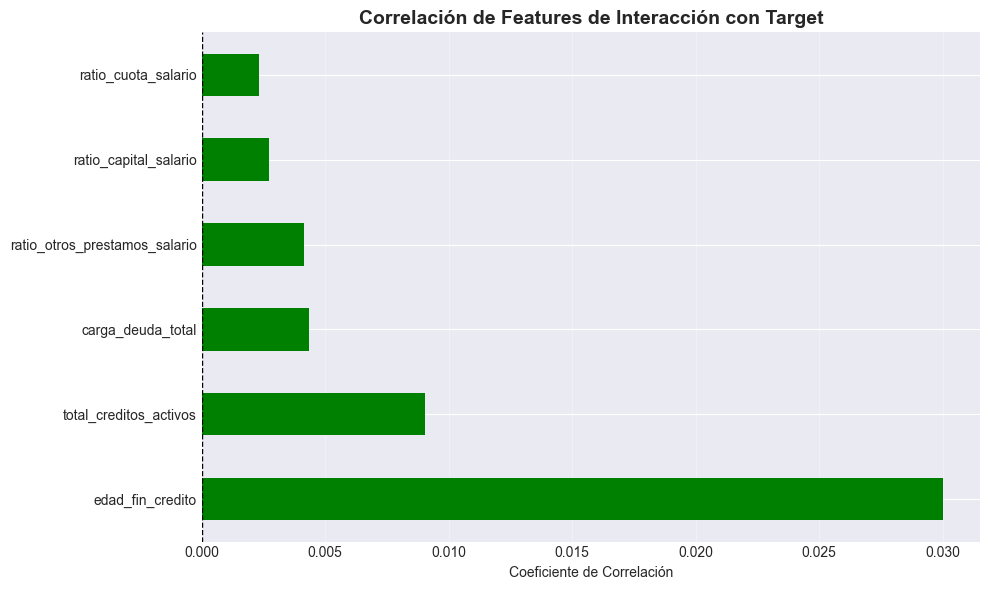


📊 INSIGHT: Features de interacción pueden capturar relaciones no lineales entre variables.


In [22]:
# Crear features de interacción relevantes para riesgo crediticio
print("Creando features de interacción...\n")

# Ratio cuota / salario
df['ratio_cuota_salario'] = df['cuota_pactada'] / (df['salario_cliente'] + 1)

# Ratio capital / salario
df['ratio_capital_salario'] = df['capital_prestado'] / (df['salario_cliente'] + 1)

# Ratio otros préstamos / salario
df['ratio_otros_prestamos_salario'] = df['total_otros_prestamos'] / (df['salario_cliente'] + 1)

# Carga total de deuda
df['carga_deuda_total'] = (df['cuota_pactada'] + df['total_otros_prestamos']) / (df['salario_cliente'] + 1)

# Edad relativa al plazo
df['edad_fin_credito'] = df['edad_cliente'] + (df['plazo_meses'] / 12)

# Total créditos activos (suma de sectores)
df['total_creditos_activos'] = (df['creditos_sectorFinanciero'] + 
                                 df['creditos_sectorCooperativo'] + 
                                 df['creditos_sectorReal'])

# Features creadas
interaction_features = ['ratio_cuota_salario', 'ratio_capital_salario', 
                        'ratio_otros_prestamos_salario', 'carga_deuda_total',
                        'edad_fin_credito', 'total_creditos_activos']

print(f"✓ Features de interacción creadas: {len(interaction_features)}")
print(interaction_features)

# Correlación de features de interacción con target
interaction_corr = df[interaction_features + ['Pago_atiempo']].corr()['Pago_atiempo'].drop('Pago_atiempo').sort_values(ascending=False)

print("\nCorrelación de features de interacción con Pago_atiempo:")
print(interaction_corr)

# Visualización
plt.figure(figsize=(10, 6))
interaction_corr.plot(kind='barh', color=interaction_corr.apply(lambda x: 'green' if x > 0 else 'red'))
plt.title('Correlación de Features de Interacción con Target', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Features de interacción pueden capturar relaciones no lineales entre variables.")

### 4.3 Análisis de Componentes Principales (PCA)

Datos para PCA: 10763 registros x 13 features


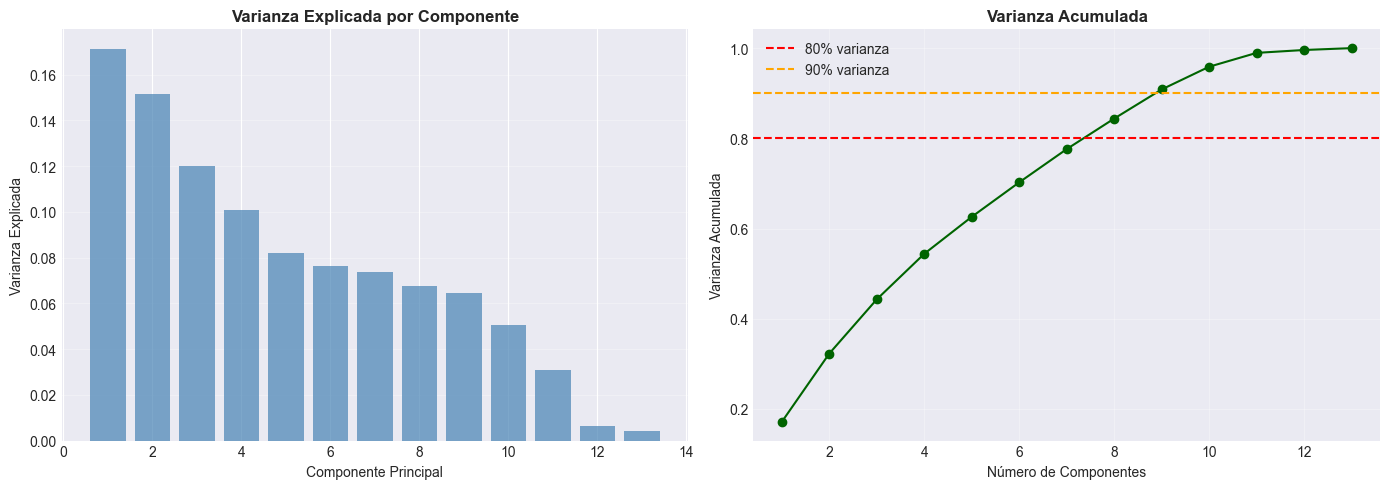


Número de componentes para 80% varianza: 8
Número de componentes para 90% varianza: 9

📊 INSIGHT: PCA puede reducir dimensionalidad manteniendo la mayor parte de la información.


In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleccionar solo variables numéricas sin nulos para PCA
pca_features = df[numeric_features].select_dtypes(include=[np.number]).dropna(axis=1)

# Remover filas con nulos
pca_df = df[pca_features.columns.tolist() + ['Pago_atiempo']].dropna()

print(f"Datos para PCA: {pca_df.shape[0]} registros x {len(pca_features.columns)} features")

# Normalizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df[pca_features.columns])

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualización de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='darkgreen')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Número de componentes para 80% y 90% de varianza
n_comp_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\nNúmero de componentes para 80% varianza: {n_comp_80}")
print(f"Número de componentes para 90% varianza: {n_comp_90}")

print("\n📊 INSIGHT: PCA puede reducir dimensionalidad manteniendo la mayor parte de la información.")

### 4.4 Visualización PCA - Primeras 2 Componentes

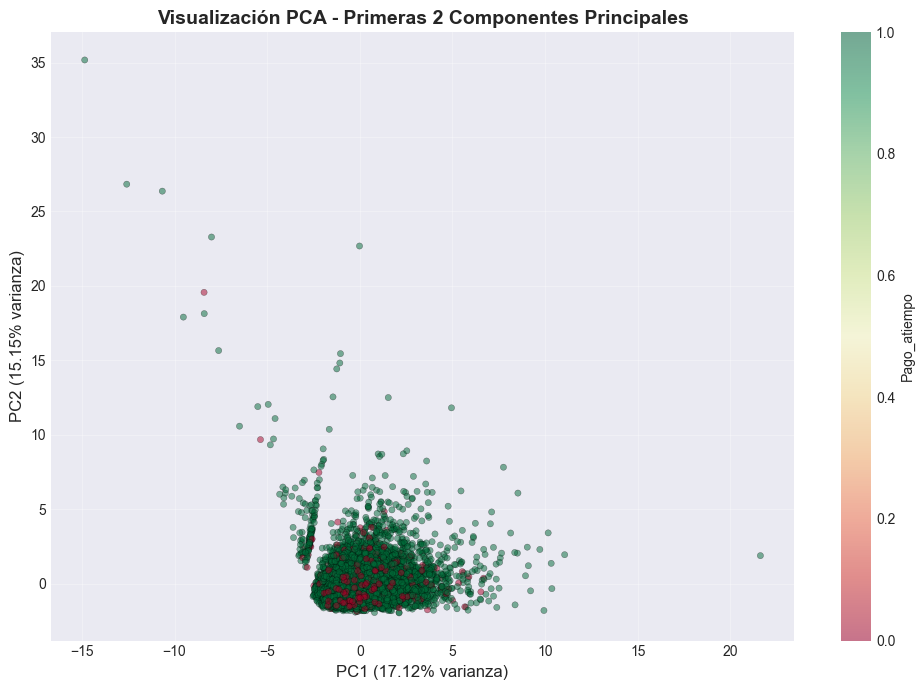


📊 INSIGHT: Buscar separación espacial entre clases (rojo=0, verde=1) en el espacio PCA.


In [24]:
# Scatter plot de las primeras 2 componentes principales
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_df['Pago_atiempo'], 
                      cmap='RdYlGn', alpha=0.5, s=20, edgecolors='k', linewidth=0.3)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% varianza)', fontsize=12)
plt.title('Visualización PCA - Primeras 2 Componentes Principales', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Pago_atiempo')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Buscar separación espacial entre clases (rojo=0, verde=1) en el espacio PCA.")

### 4.5 Segmentación por Grupos de Riesgo


Análisis por segmento_edad
                      Tasa_Pago  Cantidad  Tasa_Impago_%
segmento_edad                                           
Joven (<25)               0.912       568          8.803
Adulto Joven (25-35)      0.938      2723          6.206
Adulto (35-50)            0.962      4307          3.831
Mayor (>50)               0.962      3015          3.847


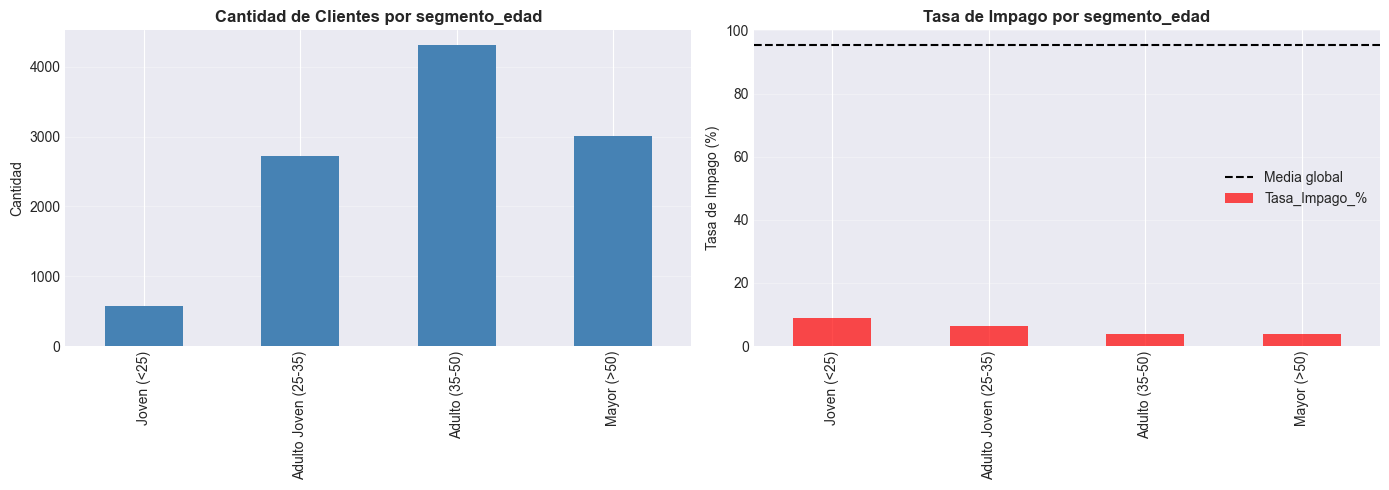


Análisis por segmento_salario
                  Tasa_Pago  Cantidad  Tasa_Impago_%
segmento_salario                                    
Bajo                  0.950      3242          4.997
Medio-Bajo            0.957      2504          4.273
Medio-Alto            0.959      2326          4.084
Alto                  0.945      2691          5.463


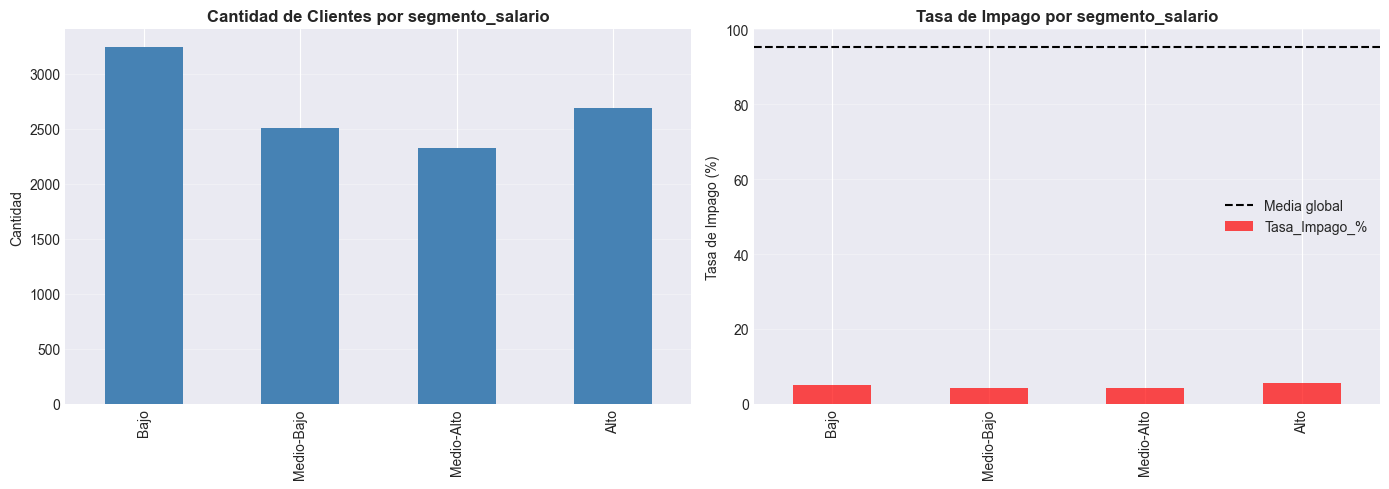


Análisis por segmento_capital
                  Tasa_Pago  Cantidad  Tasa_Impago_%
segmento_capital                                    
Pequeño               0.956      2691          4.385
Mediano               0.963      2691          3.716
Grande                0.961      2690          3.866
Muy Grande            0.930      2691          7.023


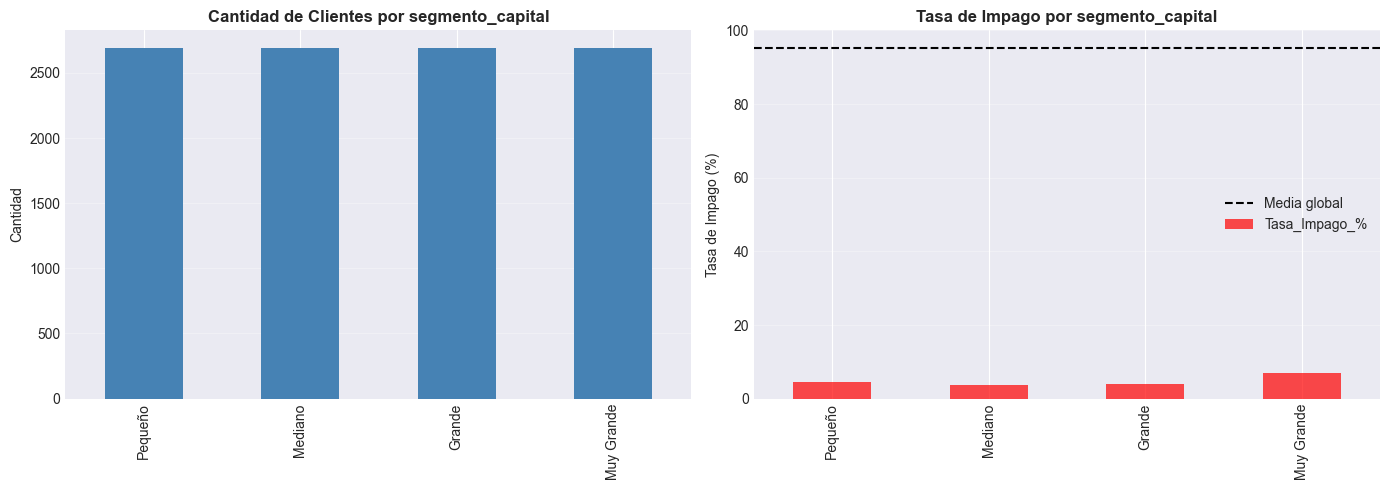


📊 INSIGHT: Identificar segmentos de alto riesgo (mayor tasa de impago) para estrategias específicas.


In [25]:
# Crear segmentos de riesgo basados en características clave

# Segmentación por edad
df['segmento_edad'] = pd.cut(df['edad_cliente'], bins=[0, 25, 35, 50, 100], 
                              labels=['Joven (<25)', 'Adulto Joven (25-35)', 'Adulto (35-50)', 'Mayor (>50)'])

# Segmentación por salario
df['segmento_salario'] = pd.qcut(df['salario_cliente'], q=4, 
                                  labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])

# Segmentación por capital prestado
df['segmento_capital'] = pd.qcut(df['capital_prestado'], q=4, 
                                  labels=['Pequeño', 'Mediano', 'Grande', 'Muy Grande'])

# Análisis de tasa de impago por segmento
segmentation_vars = ['segmento_edad', 'segmento_salario', 'segmento_capital']

for seg_var in segmentation_vars:
    print(f"\n{'='*60}")
    print(f"Análisis por {seg_var}")
    print(f"{'='*60}")
    
    # Tasa de impago por segmento
    impago_rate = df.groupby(seg_var)['Pago_atiempo'].agg(['mean', 'count'])
    impago_rate['tasa_impago'] = (1 - impago_rate['mean']) * 100
    impago_rate.columns = ['Tasa_Pago', 'Cantidad', 'Tasa_Impago_%']
    
    print(impago_rate)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cantidad por segmento
    impago_rate['Cantidad'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title(f'Cantidad de Clientes por {seg_var}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Cantidad')
    axes[0].set_xlabel('')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Tasa de impago por segmento
    impago_rate['Tasa_Impago_%'].plot(kind='bar', ax=axes[1], color='red', alpha=0.7)
    axes[1].set_title(f'Tasa de Impago por {seg_var}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Tasa de Impago (%)')
    axes[1].set_xlabel('')
    axes[1].axhline(y=df['Pago_atiempo'].mean() * 100, color='black', 
                    linestyle='--', label='Media global')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n📊 INSIGHT: Identificar segmentos de alto riesgo (mayor tasa de impago) para estrategias específicas.")

---

## 5. Conclusiones y Recomendaciones

### 5.1 Resumen de Hallazgos Principales

In [26]:
print("="*80)
print("RESUMEN DE HALLAZGOS PRINCIPALES DEL EDA")
print("="*80)

print("\n1. DESBALANCE DE CLASES:")
print(f"   - 95.25% de clientes pagaron a tiempo")
print(f"   - 4.75% de clientes NO pagaron a tiempo")
print(f"   - Ratio de desbalance: {balance_ratio:.3f}")
print(f"   ⚠ Requiere técnicas de balanceo (SMOTE, class_weight, undersampling)")

print("\n2. VALORES NULOS:")
print(f"   - Variables de Datacredito: ~27% nulos (tendencia_ingresos, promedio_ingresos_datacredito)")
print(f"   - Variables de saldo: 1.45%-5.48% nulos")
print(f"   ⚠ Estrategia: Imputación con mediana/moda o crear flag 'sin_historial_datacredito'")

print("\n3. CORRELACIONES CON TARGET:")
print("   Top 5 variables más correlacionadas:")
for i, (var, corr) in enumerate(target_correlation.head(5).items(), 1):
    print(f"   {i}. {var}: {corr:.4f}")

print("\n4. OUTLIERS:")
outlier_vars = outlier_df[outlier_df['Porcentaje'] > 5]['Variable'].tolist()
print(f"   - {len(outlier_vars)} variables con >5% de outliers")
if len(outlier_vars) > 0:
    print(f"   - Variables: {outlier_vars[:5]}")
print(f"   ⚠ Considerar transformación log o winsorización")

print("\n5. VARIABLES CATEGÓRICAS:")
print(f"   - tipo_laboral: {df['tipo_laboral'].nunique()} categorías")
print(f"   - tendencia_ingresos: {df['tendencia_ingresos'].nunique()} categorías")
print(f"   ⚠ Chi-cuadrado indicó asociación significativa con target")

print("\n6. FEATURES DE INTERACCIÓN:")
print("   - ratio_cuota_salario: Importante para medir capacidad de pago")
print("   - carga_deuda_total: Captura endeudamiento total del cliente")
print("   - total_creditos_activos: Suma de créditos en todos los sectores")
print(f"   ⚠ Estas features pueden mejorar el poder predictivo del modelo")

print("\n" + "="*80)

RESUMEN DE HALLAZGOS PRINCIPALES DEL EDA

1. DESBALANCE DE CLASES:
   - 95.25% de clientes pagaron a tiempo
   - 4.75% de clientes NO pagaron a tiempo
   - Ratio de desbalance: 0.050
   ⚠ Requiere técnicas de balanceo (SMOTE, class_weight, undersampling)

2. VALORES NULOS:
   - Variables de Datacredito: ~27% nulos (tendencia_ingresos, promedio_ingresos_datacredito)
   - Variables de saldo: 1.45%-5.48% nulos
   ⚠ Estrategia: Imputación con mediana/moda o crear flag 'sin_historial_datacredito'

3. CORRELACIONES CON TARGET:
   Top 5 variables más correlacionadas:
   1. puntaje: 0.9231
   2. puntaje_datacredito: 0.0679
   3. promedio_ingresos_datacredito: 0.0399
   4. edad_cliente: 0.0323
   5. creditos_sectorFinanciero: 0.0214

4. OUTLIERS:
   - 10 variables con >5% de outliers
   - Variables: ['creditos_sectorCooperativo', 'puntaje', 'saldo_total', 'saldo_principal', 'plazo_meses']
   ⚠ Considerar transformación log o winsorización

5. VARIABLES CATEGÓRICAS:
   - tipo_laboral: 2 categorí

### 5.2 Recomendaciones para Feature Engineering

In [27]:
print("="*80)
print("RECOMENDACIONES PARA FEATURE ENGINEERING")
print("="*80)

print("\n1. TRATAMIENTO DE VALORES NULOS:")
print("   a) Variables de Datacredito (27% nulos):")
print("      - Crear feature binaria: 'sin_historial_datacredito'")
print("      - Imputar con mediana para variables numéricas")
print("      - Imputar con moda para tendencia_ingresos")
print("   b) Variables de saldo (<6% nulos):")
print("      - Imputar con mediana")

print("\n2. MANEJO DE OUTLIERS:")
print("   - Aplicar transformación logarítmica a variables con sesgo fuerte")
print("   - Considerar winsorización para variables financieras (percentiles 1-99)")
print("   - Mantener outliers si son representativos del negocio")

print("\n3. ENCODING DE VARIABLES CATEGÓRICAS:")
print("   - tipo_laboral: OneHotEncoder (nominal)")
print("   - tendencia_ingresos: OrdinalEncoder (ordinal: Creciente > Estable > Decreciente)")

print("\n4. FEATURES TEMPORALES:")
print("   - Extraer: año_prestamo, mes_prestamo, dia_semana_prestamo")
print("   - Crear: edad_fin_credito (edad + plazo_meses/12)")

print("\n5. FEATURES DE INTERACCIÓN (PRIORITARIAS):")
print("   ✓ ratio_cuota_salario = cuota_pactada / salario_cliente")
print("   ✓ ratio_capital_salario = capital_prestado / salario_cliente")
print("   ✓ carga_deuda_total = (cuota_pactada + total_otros_prestamos) / salario_cliente")
print("   ✓ total_creditos_activos = suma(creditos_sector*)")
print("   ✓ ratio_saldo_capital = saldo_total / capital_prestado")

print("\n6. NORMALIZACIÓN/ESTANDARIZACIÓN:")
print("   - Aplicar StandardScaler a variables numéricas")
print("   - Usar dentro de Pipeline de sklearn para evitar data leakage")

print("\n7. BALANCEO DE CLASES:")
print("   Opciones:")
print("   a) SMOTE (Synthetic Minority Over-sampling Technique)")
print("   b) class_weight='balanced' en modelos que lo soporten")
print("   c) Undersampling de clase mayoritaria")
print("   d) Combinación de over/undersampling (SMOTETomek)")

print("\n8. SELECCIÓN DE FEATURES:")
print("   - Eliminar features con correlación >0.9 (multicolinealidad)")
print("   - Usar SelectKBest o RFE para ranking de importancia")
print("   - Feature importance de modelos tree-based (Random Forest, XGBoost)")

print("\n" + "="*80)

RECOMENDACIONES PARA FEATURE ENGINEERING

1. TRATAMIENTO DE VALORES NULOS:
   a) Variables de Datacredito (27% nulos):
      - Crear feature binaria: 'sin_historial_datacredito'
      - Imputar con mediana para variables numéricas
      - Imputar con moda para tendencia_ingresos
   b) Variables de saldo (<6% nulos):
      - Imputar con mediana

2. MANEJO DE OUTLIERS:
   - Aplicar transformación logarítmica a variables con sesgo fuerte
   - Considerar winsorización para variables financieras (percentiles 1-99)
   - Mantener outliers si son representativos del negocio

3. ENCODING DE VARIABLES CATEGÓRICAS:
   - tipo_laboral: OneHotEncoder (nominal)
   - tendencia_ingresos: OrdinalEncoder (ordinal: Creciente > Estable > Decreciente)

4. FEATURES TEMPORALES:
   - Extraer: año_prestamo, mes_prestamo, dia_semana_prestamo
   - Crear: edad_fin_credito (edad + plazo_meses/12)

5. FEATURES DE INTERACCIÓN (PRIORITARIAS):
   ✓ ratio_cuota_salario = cuota_pactada / salario_cliente
   ✓ ratio_capita

### 5.3 Variables Clave Identificadas

In [28]:
print("="*80)
print("VARIABLES CLAVE PARA EL MODELO PREDICTIVO")
print("="*80)

# Top 10 variables por correlación absoluta
top_10_vars = target_correlation.abs().sort_values(ascending=False).head(10)

print("\nTop 10 Variables por Correlación con Target:")
for i, (var, corr) in enumerate(top_10_vars.items(), 1):
    direction = "Positiva" if target_correlation[var] > 0 else "Negativa"
    print(f"{i:2d}. {var:40s} | Corr: {target_correlation[var]:7.4f} ({direction})")

print("\n" + "="*80)
print("INTERPRETACIÓN DE NEGOCIO:")
print("="*80)
print("\nLas variables con CORRELACIÓN POSITIVA indican que a mayor valor, mayor probabilidad de pago.")
print("Las variables con CORRELACIÓN NEGATIVA indican que a mayor valor, menor probabilidad de pago.")
print("\nEsto permitirá al modelo identificar perfiles de riesgo crediticio.")

print("\n" + "="*80)

VARIABLES CLAVE PARA EL MODELO PREDICTIVO

Top 10 Variables por Correlación con Target:
 1. puntaje                                  | Corr:  0.9231 (Positiva)
 2. huella_consulta                          | Corr: -0.0737 (Negativa)
 3. saldo_mora                               | Corr: -0.0735 (Negativa)
 4. puntaje_datacredito                      | Corr:  0.0679 (Positiva)
 5. plazo_meses                              | Corr: -0.0631 (Negativa)
 6. capital_prestado                         | Corr: -0.0406 (Negativa)
 7. promedio_ingresos_datacredito            | Corr:  0.0399 (Positiva)
 8. edad_cliente                             | Corr:  0.0323 (Positiva)
 9. creditos_sectorReal                      | Corr: -0.0233 (Negativa)
10. creditos_sectorFinanciero                | Corr:  0.0214 (Positiva)

INTERPRETACIÓN DE NEGOCIO:

Las variables con CORRELACIÓN POSITIVA indican que a mayor valor, mayor probabilidad de pago.
Las variables con CORRELACIÓN NEGATIVA indican que a mayor valor, men

### 5.4 Próximos Pasos

In [29]:
print("="*80)
print("PRÓXIMOS PASOS - AVANCE #2")
print("="*80)

print("\n1. FEATURE ENGINEERING (ft_engineering.py):")
print("   ✓ Implementar funciones de imputación de valores nulos")
print("   ✓ Crear features de interacción identificadas en el EDA")
print("   ✓ Implementar ColumnTransformer con pipelines separados:")
print("      - Pipeline numérico: SimpleImputer(median) → StandardScaler")
print("      - Pipeline categórico nominal: SimpleImputer(most_frequent) → OneHotEncoder")
print("      - Pipeline categórico ordinal: SimpleImputer(most_frequent) → OrdinalEncoder")
print("   ✓ Guardar pipeline ajustado para uso en producción")

print("\n2. MODELADO (model_training_evaluation.py):")
print("   ✓ Cargar y preprocesar datos")
print("   ✓ Split 80/20 estratificado (train/test)")
print("   ✓ Aplicar técnica de balanceo (SMOTE o class_weight)")
print("   ✓ Entrenar múltiples modelos:")
print("      1. Logistic Regression (baseline)")
print("      2. Decision Tree")
print("      3. Random Forest")
print("      4. XGBoost")
print("      5. Gradient Boosting")
print("   ✓ Validación cruzada estratificada (5 folds)")
print("   ✓ Optimización de hiperparámetros (GridSearch/RandomSearch)")
print("   ✓ Evaluación con métricas:")
print("      - ROC-AUC (primaria para crédito)")
print("      - Precision, Recall, F1-Score")
print("      - Confusion Matrix")
print("      - Curvas ROC y Precision-Recall")
print("   ✓ Interpretación de resultados desde perspectiva de negocio")
print("   ✓ Seleccionar mejor modelo y guardar en mlops_pipeline/models/")

print("\n3. CRITERIOS DE ÉXITO:")
print("   - ROC-AUC > 0.70 (esperado)")
print("   - ROC-AUC > 0.75 (excelente)")
print("   - Recall alto para minimizar falsos negativos (riesgo crediticio)")
print("   - Modelo interpretable para decisiones de negocio")

print("\n" + "="*80)
print("✓ ANÁLISIS EXPLORATORIO COMPLETADO")
print("="*80)

PRÓXIMOS PASOS - AVANCE #2

1. FEATURE ENGINEERING (ft_engineering.py):
   ✓ Implementar funciones de imputación de valores nulos
   ✓ Crear features de interacción identificadas en el EDA
   ✓ Implementar ColumnTransformer con pipelines separados:
      - Pipeline numérico: SimpleImputer(median) → StandardScaler
      - Pipeline categórico nominal: SimpleImputer(most_frequent) → OneHotEncoder
      - Pipeline categórico ordinal: SimpleImputer(most_frequent) → OrdinalEncoder
   ✓ Guardar pipeline ajustado para uso en producción

2. MODELADO (model_training_evaluation.py):
   ✓ Cargar y preprocesar datos
   ✓ Split 80/20 estratificado (train/test)
   ✓ Aplicar técnica de balanceo (SMOTE o class_weight)
   ✓ Entrenar múltiples modelos:
      1. Logistic Regression (baseline)
      2. Decision Tree
      3. Random Forest
      4. XGBoost
      5. Gradient Boosting
   ✓ Validación cruzada estratificada (5 folds)
   ✓ Optimización de hiperparámetros (GridSearch/RandomSearch)
   ✓ Evaluación

---

## Fin del Análisis Exploratorio

**Autor:** Juan Carlos López S. 
**Fecha:** Mayo 2026  
**Versión:** V1.0.1  
**Proyecto:** MLOps Pipeline - Predicción de Riesgo Crediticio  

Este análisis exploratorio proporciona una base sólida para el desarrollo de features y modelado predictivo en los siguientes avances del proyecto.